# Evaluate real-network benchmark results (full inference, all 8 networks)

Computes precision / recall / F1 (plus AUPRC as a fully threshold-free metric) for every BEELINE `rankedEdges.csv`, and for TwINFER's own current `*_all_results.json` output in `analysis_data/paper_analysis/real_networks/twinfer_inference/`, against each network's `GroundTruthNetwork.csv` -- all 8 real networks: GSD, HSC, mCAD, VSC (literature-curated, TwINFER's own Gillespie simulator) and B_cell_activation, Circadian_cycle, EMT, Pluripotent (literature-curated, this repo's `real_network_sim.py` pipeline). Same methodology as `evaluate_networksweep_final_beeline.ipynb`.

TwINFER's output here comes from a full-inference run of `infer_network_simulation_real_network.py`: GSD/HSC/mCAD/VSC restricted to exactly the replicates BEELINE was run on (matched by the raw simulation file's hash), B_cell_activation/Circadian_cycle/EMT/Pluripotent run over every replicate on disk -- more than BEELINE's own coverage for EMT/Pluripotent, intentionally not capped down to match (see the "no replicate cap" section below).

GSD/HSC/mCAD/VSC's BEELINE comparison run was originally staged on Quest scratch (`/scratch/gzu5140/twinfer_real/`); scratch is purged after ~30 days of inactivity, which already took out that run's `GroundTruthNetwork.csv` files (broken symlinks) before this run of the notebook. It's now copied locally to `benchmarking_analysis/twinfer_real/` (non-purged, shared storage) so it doesn't disappear again, and ground truth for those 4 networks is rebuilt directly from `input_data/real_world_networks/*.txt` (the original source those GroundTruthNetwork.csv files were generated from) rather than depended on staying in the scratch copy.

## Two threshold strategies -- computed and reported side by side

`rankedEdges.csv` is a *ranking*, not a binary prediction, so precision/recall/F1 need a cutoff. There isn't one universal cutoff that's fair to every algorithm, because algorithms differ in kind:

- **Top-k, tie-aware** -- for algorithms that output a genuine continuous ranking over the *full* edge space (e.g. correlation/MI scores for every possible pair). k = number of true edges in the ground truth (excluding self-loops); this mirrors BEELINE's own `EarlyPrecision` evaluator (`BLEval/EarlyPrecision.py`) exactly, including its tie-aware boundary (`best_val = max(smallest nonzero weight, weight of the k-th ranked edge)`, expanding to include all ties at that value rather than an arbitrary hard slice).
- **Natural / self-thresholded** -- for algorithms that internally make their own hard include/exclude decision and only assign a nonzero (or present) weight to edges they've decided are real (e.g. a significance test, or a fixed-size candidate-regulator list). Forcing these to the same top-k cutoff as the ground truth's edge count is unfair: a method that confidently outputs 6 edges when the true network has 17 shouldn't be penalized for not padding out to 17. This strategy just uses whatever the algorithm itself flagged as nonzero, with no truncation or padding.

Reporting both is also diagnostic: if an algorithm's two sets of numbers diverge a lot, that's a sign it's the "outputs its own fixed network" type rather than the "continuous ranking" type -- worth knowing regardless of which number you end up citing.

**AUPRC** (mirroring `BLEval/AUPRC.py`'s exact scoring-universe construction) is also computed as a fully threshold-free complementary metric.

## TwINFER here is scored from its ranked_edges / TwinScore output, not a precomputed CSV

TwINFER's results only exist as raw `<sim_type>_rep_<rep_id>_all_results.json` files, one per (sim_type, replicate). Each carries `result["ranked_edges"]` -- every directed candidate pair's `twinScore` (continuous, signed) -- which this notebook treats exactly like a BEELINE algorithm's `rankedEdges.csv` (`twinScore` as `EdgeWeight`): same top-k / natural / AUPRC / signed / undirected pipeline, no special-casing, so TwINFER sits on identical footing to every other method rather than getting its own bespoke scoring path. The JSON also carries a `directed_edges` hard-decision list (TwINFER's own thresholding) that is **not** used here -- `precision_natural`/`recall_natural`/etc. for TwINFER currently come from `ranked_edges`'s nonzero `twinScore` entries, the same convention applied to every other continuous-score method (PEARSON, PIDC, ...).


In [1]:
import json
import re
from itertools import combinations, permutations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, precision_recall_curve

from twinfer.utils.paths import get_data_root

DATA_ROOT = get_data_root()
PROJECT_ROOT = DATA_ROOT.parent

# GSD/HSC/mCAD/VSC: BEELINE run on TwINFER's own Gillespie-simulated data,
# copied locally from Quest scratch into benchmarking_analysis/ (see the
# intro cell -- the scratch original had already lost its ground-truth files
# to the ~30-day purge). Ground truth for these 4 is rebuilt directly from
# the original topology matrices instead of relying on that copy.
LEGACY_OUTPUT_ROOT = PROJECT_ROOT / "benchmarking_analysis" / "twinfer_real" / "outputs"
LEGACY_TOPOLOGY_ROOT = PROJECT_ROOT / "input_data" / "real_world_networks"
LEGACY_TOPOLOGY_FILES = {"GSD": "GSD.txt", "HSC": "HSC.txt", "VSC": "VSC.txt", "mCAD": "mCAD.txt"}

# B_cell_activation/Circadian_cycle/EMT/Pluripotent: BEELINE run under this
# repo's own Beeline checkout, output living directly under analysis_data
# (not scratch).
CURRENT_INPUT_ROOT = PROJECT_ROOT / "code" / "Beeline" / "inputs" / "real_networks"
CURRENT_OUTPUT_ROOT = DATA_ROOT / "paper_analysis" / "real_networks" / "beeline_inference"

# dataset_id -> BEELINE output_root (rankedEdges.csv lives at
# output_root/dataset_id/simrep<rep>_<scheme>/<algorithm>/rankedEdges.csv for
# every dataset, legacy and current alike).
REAL_NETWORK_DATASETS = {
    "GSD": LEGACY_OUTPUT_ROOT, "HSC": LEGACY_OUTPUT_ROOT,
    "VSC": LEGACY_OUTPUT_ROOT, "mCAD": LEGACY_OUTPUT_ROOT,
    "B_cell_activation": CURRENT_OUTPUT_ROOT, "Circadian_cycle": CURRENT_OUTPUT_ROOT,
    "EMT": CURRENT_OUTPUT_ROOT, "Pluripotent": CURRENT_OUTPUT_ROOT,
}

# TwINFER's own full-inference output (infer_network_simulation_real_network.py).
TWINFER_JSON_ROOT = DATA_ROOT / "paper_analysis" / "real_networks" / "twinfer_inference"

OUT_DIR = DATA_ROOT / "paper_analysis" / "real_networks"
RESULTS_CSV = OUT_DIR / "real_networks_full_inference_evaluation_metrics.csv"

# Matches e.g. "simrep0_spread" (current-track integer rep) or
# "simrep117c4801_spread" (legacy-track hash rep) -> sim_rep, scheme.
RUN_ID_RE = re.compile(r"^simrep([0-9a-fA-F]+)_(spread|twin_paired)$")

# --------------------------------------------------------------------
# Canonical "natural" threshold (ported from benchmark_network_sweep.ipynb):
# a real method-native significance metric for PPCOR/PEARSON/SCSGL, GMM
# density-crossover for everything else (incl. TwINFER) -- not the crude
# nonzero-weight rule this notebook used before. See native_threshold_for_algorithm.
# --------------------------------------------------------------------
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq
import sys

# ExpressionData.csv per run (needed only for SCSGL's native permutation
# threshold, recomputed on the same input SCSGL's run originally used).
LEGACY_INPUT_ROOT = PROJECT_ROOT / "code" / "Beeline" / "inputs" / "real_networks_legacy"
REAL_NETWORK_INPUT_ROOTS = {
    "GSD": LEGACY_INPUT_ROOT, "HSC": LEGACY_INPUT_ROOT,
    "VSC": LEGACY_INPUT_ROOT, "mCAD": LEGACY_INPUT_ROOT,
    "B_cell_activation": CURRENT_INPUT_ROOT, "Circadian_cycle": CURRENT_INPUT_ROOT,
    "EMT": CURRENT_INPUT_ROOT, "Pluripotent": CURRENT_INPUT_ROOT,
}

_SCSGL_PYSRC_DIR = PROJECT_ROOT / "code" / "Beeline" / "Algorithms" / "SCSGL" / "scSGL"
if str(_SCSGL_PYSRC_DIR) not in sys.path:
    sys.path.append(str(_SCSGL_PYSRC_DIR))
from pysrc.associations.correlation import permutations as scsgl_correlation_permutations


## Core evaluation logic

`build_edge_universe` and `top_k_tie_aware_selection` mirror `BLEval/EarlyPrecision.py`'s `_build_edge_universe`/`_compute_early_precision` exactly (directed non-self-loop gene pairs; `tf_edges=False`, appropriate for this synthetic data). `compute_auprc` mirrors `BLEval/AUPRC.py`'s `_compute_auprc` exactly. `natural_threshold_selection` is new -- there's no equivalent in `BLEval/`, since BEELINE itself only ever evaluates at the top-k cutoff.

In [2]:
def load_ground_truth(dataset_id: str) -> pd.DataFrame:
    if dataset_id in LEGACY_TOPOLOGY_FILES:
        # GSD/HSC/mCAD/VSC's own GroundTruthNetwork.csv was lost to the
        # scratch purge (see intro cell) -- rebuild it from the same signed
        # adjacency matrix it was originally generated from, using the same
        # gene_1..gene_N labeling convention BEELINE was actually run on
        # (matches twinfer_to_boolode_format.py's convert_ground_truth).
        matrix = pd.read_csv(
            LEGACY_TOPOLOGY_ROOT / LEGACY_TOPOLOGY_FILES[dataset_id], header=None
        ).to_numpy()
        n_genes = matrix.shape[0]
        gene_names = [f"gene_{i + 1}" for i in range(n_genes)]
        edges = [
            (gene_names[i], gene_names[j], "+" if matrix[i, j] > 0 else "-")
            for i in range(n_genes)
            for j in range(n_genes)
            if matrix[i, j] != 0
        ]
        return pd.DataFrame(edges, columns=["Gene1", "Gene2", "Type"])

    gt_path = CURRENT_INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
    return pd.read_csv(gt_path, header=0)


def build_edge_universe(gt_df: pd.DataFrame):
    """All directed non-self-loop gene pairs among GT genes, and the true-edge subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = set(permutations(unique_nodes, 2))
    true_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"])) & possible_edges
    return possible_edges, true_edges

def dedupe_predictions(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; keep the highest |EdgeWeight| per (Gene1, Gene2)."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    # NaN EdgeWeight (e.g. PPCOR's partial correlation is undefined for a pair
    # involving a zero-variance gene) is treated as no evidence of an edge, not
    # a crash -- same convention as a natural-threshold selection excluding it.
    pred["_abs"] = pred["EdgeWeight"].fillna(0.0).abs()
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["Gene1", "Gene2"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection(predicted: pd.DataFrame, num_true_edges: int):
    """
    Select the top-k predictions (k = num_true_edges), expanded to include all
    ties at the boundary weight -- same logic as
    BLEval.EarlyPrecision._compute_early_precision. Returns (selected_edge_set,
    threshold_weight_used).
    """
    if predicted.empty or num_true_edges == 0:
        return set(), float("nan")

    maxk = min(len(predicted), num_true_edges)
    edge_weight_topk = float(predicted.iloc[maxk - 1]["_abs"])

    nonzero = predicted.loc[predicted["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted[predicted["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"])), best_val


def natural_threshold_selection(predicted: pd.DataFrame):
    """
    Use whatever edges the algorithm itself assigned a nonzero weight to --
    no truncation or padding to match the ground truth's edge count. Fair to
    algorithms that make their own hard include/exclude decision (e.g. a
    significance test, or a fixed-size candidate-regulator list) rather than
    emitting a full continuous ranking meant to be externally truncated.
    """
    if predicted.empty:
        return set()
    selected = predicted[predicted["_abs"] > 0]
    return set(zip(selected["Gene1"], selected["Gene2"]))


def precision_recall_f1(selected_edges: set, true_edges: set):
    if not selected_edges:
        return 0.0, 0.0, 0.0
    tp = len(selected_edges & true_edges)
    precision = tp / len(selected_edges)
    recall = tp / len(true_edges) if true_edges else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def compute_auprc(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """Fully threshold-free complementary metric -- mirrors BLEval.AUPRC._compute_auprc exactly."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    true_edge_set = set(zip(gt_df["Gene1"], gt_df["Gene2"]))

    pred = dedupe_predictions(ranked_edges)
    pred_lookup = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))

    true_labels = [1 if e in true_edge_set else 0 for e in possible_edges]
    pred_scores = [pred_lookup.get(e, 0.0) for e in possible_edges]

    if sum(true_labels) == 0:
        return float("nan")

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


## Two additional comparison strictness levels: signed+directed, and undirected+unsigned

The metrics above (`build_edge_universe`, `top_k_tie_aware_selection`, etc.) are directed but **sign-blind** -- a predicted `A->B` counts as correct regardless of whether the ground truth's `Type` (`+`/`-`) matches. Two more strictness levels bracket that:

- **Signed + directed** (`*_signed`) -- the strictest: a predicted edge only counts as correct if it matches the ground truth's `(Gene1, Gene2, Type)` exactly. Any mismatch -- wrong direction, wrong sign, or both -- is incorrect, full stop. For `auprc_signed` specifically: a wrong-sign prediction is scored as an **explicit false positive**, not merely an unscored miss. The scoring universe is every directed pair x both signs; a prediction's magnitude is only credited to the sign-position it actually predicted, so predicting `(A,B)` with the wrong sign shows up as a confident wrong answer at that rank (hurting precision), while the true `(A,B,true_sign)` position gets zero credit (a guaranteed miss for that edge) -- both consequences of the mismatch are real, not free.
- **Undirected + unsigned** (`*_undirected`) -- the most lenient: only "is there *any* relationship between these two genes" is evaluated. `(A,B)` and `(B,A)` collapse into one position (`frozenset({A,B})`), scored by whichever direction the algorithm ranked higher; sign is ignored entirely.

`n_true_edges_signed` and `n_true_edges_undirected` are computed separately per dataset (not assumed equal to the original `n_true_edges`), since a ground truth with any mutual/bidirectional regulation collapses to fewer undirected edges than directed ones.

**Partially available for TwINFER's fold-in rows below**: `twinfer_analysis_output.csv` now carries all three AUPRC levels (`auprc`, `auprc_signed`, `auprc_undirected`), computed in `network_sweep_analysis.ipynb` directly from each result JSON's `ranked_edge_list` (which has `directional_correlation`'s sign as the predicted sign) against the signed ground-truth matrix -- the same scoring-universe conventions as `compute_auprc_signed`/`compute_auprc_undirected` above. The `precision_topk_signed`/`recall_topk_signed`/etc. threshold-based columns are still `NaN` for TwINFER, since the summary CSV only carries directed, sign-blind TP/FP/FN/precision/recall/f1 (plus a `wrong_sign_edge` *count*, not a full re-derivable breakdown) -- there's no per-edge prediction set left to threshold at top-k or "natural" for the signed/undirected cases.

In [3]:
def build_signed_edge_universe(gt_df: pd.DataFrame):
    """Directed non-self-loop (Gene1, Gene2, Type) true-edge triples."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    true_signed_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"], gt_no_self["Type"]))
    return true_signed_edges


def build_undirected_edge_universe(gt_df: pd.DataFrame):
    """All undirected non-self-loop gene pairs among GT genes (as frozensets), and the true subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = {frozenset(p) for p in combinations(unique_nodes, 2)}
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_no_self["Gene1"], gt_no_self["Gene2"])}
    return possible_pairs, true_pairs


def add_predicted_sign(predicted: pd.DataFrame) -> pd.DataFrame:
    """Attach a '+'/'-' predicted sign column derived from EdgeWeight's sign."""
    pred = predicted.copy()
    pred["_sign"] = np.where(pred["EdgeWeight"] >= 0, "+", "-")
    return pred


def top_k_tie_aware_selection_signed(predicted_signed: pd.DataFrame, num_true_edges: int):
    """Same top-k tie-aware boundary logic as top_k_tie_aware_selection, but selects and
    returns (Gene1, Gene2, predicted_sign) triples instead of (Gene1, Gene2) pairs."""
    if predicted_signed.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_signed), num_true_edges)
    edge_weight_topk = float(predicted_signed.iloc[maxk - 1]["_abs"])
    nonzero = predicted_signed.loc[predicted_signed["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_signed[predicted_signed["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"])), best_val


def natural_threshold_selection_signed(predicted_signed: pd.DataFrame):
    if predicted_signed.empty:
        return set()
    selected = predicted_signed[predicted_signed["_abs"] > 0]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"]))


def compute_auprc_signed(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """
    AUPRC over directed AND signed edges. Scoring universe is every directed pair x both
    signs, so a wrong-signed prediction is scored as an explicit false positive (full
    magnitude credited to the *wrong* sign-position) rather than merely withheld -- see the
    markdown cell above for why.
    """
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    possible_signed_positions = [(g1, g2, s) for (g1, g2) in possible_edges for s in ("+", "-")]

    true_signed_edges = build_signed_edge_universe(gt_df)

    pred = dedupe_predictions(ranked_edges)
    pred = add_predicted_sign(pred)
    pred_score_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))
    pred_sign_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_sign"]))

    true_labels, pred_scores = [], []
    for (g1, g2, s) in possible_signed_positions:
        true_labels.append(1 if (g1, g2, s) in true_signed_edges else 0)
        predicted_sign_here = pred_sign_by_pair.get((g1, g2))
        score = pred_score_by_pair.get((g1, g2), 0.0) if predicted_sign_here == s else 0.0
        pred_scores.append(score)

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def dedupe_predictions_undirected(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; collapse (Gene1,Gene2) and (Gene2,Gene1) into one undirected edge
    (frozenset pair), keeping the highest |EdgeWeight| between the two directions."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    # NaN EdgeWeight (e.g. PPCOR's partial correlation is undefined for a pair
    # involving a zero-variance gene) is treated as no evidence of an edge, not
    # a crash -- same convention as a natural-threshold selection excluding it.
    pred["_abs"] = pred["EdgeWeight"].fillna(0.0).abs()
    pred["_pair"] = [frozenset(p) for p in zip(pred["Gene1"], pred["Gene2"])]
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection_undirected(predicted_undirected: pd.DataFrame, num_true_edges: int):
    if predicted_undirected.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_undirected), num_true_edges)
    edge_weight_topk = float(predicted_undirected.iloc[maxk - 1]["_abs"])
    nonzero = predicted_undirected.loc[predicted_undirected["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_undirected[predicted_undirected["_abs"] >= best_val]
    return set(selected["_pair"]), best_val


def natural_threshold_selection_undirected(predicted_undirected: pd.DataFrame):
    if predicted_undirected.empty:
        return set()
    selected = predicted_undirected[predicted_undirected["_abs"] > 0]
    return set(selected["_pair"])


def compute_auprc_undirected(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over undirected, unsigned edges -- only presence of a relationship is scored."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = [frozenset(p) for p in combinations(gt_genes, 2)]
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_df["Gene1"], gt_df["Gene2"])}

    pred = dedupe_predictions_undirected(ranked_edges)
    pred_lookup = dict(zip(pred["_pair"], pred["_abs"].astype(float)))

    true_labels = [1 if p in true_pairs else 0 for p in possible_pairs]
    pred_scores = [pred_lookup.get(p, 0.0) for p in possible_pairs]

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))

In [4]:
def fit_gmm_threshold(scores, min_points=2, random_state=0):
    """
    Fits a 2-component GaussianMixture on `scores` and returns (gmm, threshold,
    threshold_type) -- ported verbatim from benchmark_network_sweep.ipynb. threshold is
    the intersection of the two components' weighted PDFs (via brentq between the two
    component means): a data-driven cutoff rather than an externally chosen rank
    (top-k) or an arbitrary fixed value.

    Returns (None, np.inf, "GMM_too_few_points") if there aren't enough distinct values
    to fit two components; (gmm, np.inf, "GMM_no_intersection") if the fit succeeds but
    the two components don't cross within their means.

    Fallback path -- used for every method with no native significance metric (PIDC,
    GENIE3, GRNBOOST2, SCODE, and TwINFER). PPCOR, SCSGL, PEARSON instead use a real
    method-native metric when available; see native_threshold_for_algorithm.
    """
    x = np.asarray(scores).reshape(-1, 1)
    if len(x) < min_points or len(np.unique(x)) < 2:
        return None, np.inf, "GMM_too_few_points"

    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=random_state)
    gmm.fit(x)

    weights = gmm.weights_
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    w1, w2 = weights[order]
    m1, m2 = means[order]
    s1, s2 = stds[order]

    f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)
    try:
        threshold = brentq(f, m1, m2)
        return gmm, threshold, "GMM_intersection"
    except ValueError:
        return gmm, np.inf, "GMM_no_intersection"


def gmm_natural_threshold_selection(predicted: pd.DataFrame, threshold: float):
    if predicted.empty:
        return set()
    selected = predicted[predicted["_abs"] >= threshold]
    return set(zip(selected["Gene1"], selected["Gene2"]))


def gmm_natural_threshold_selection_signed(predicted_signed: pd.DataFrame, threshold: float):
    if predicted_signed.empty:
        return set()
    selected = predicted_signed[predicted_signed["_abs"] >= threshold]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"]))


def gmm_natural_threshold_selection_undirected(predicted_undirected: pd.DataFrame, threshold: float):
    if predicted_undirected.empty:
        return set()
    selected = predicted_undirected[predicted_undirected["_abs"] >= threshold]
    return set(selected["_pair"])


# --- Native significance metrics (replace GMM for PPCOR/SCSGL/PEARSON) ---
#
# rankedEdges.csv strips every method down to a bare Gene1/Gene2/EdgeWeight triple, but
# three methods have a real significance test sitting on disk, unused by that file:
#   - PPCOR:   a genuine Spearman partial-correlation p-value (ppcor::pcor), in
#              working_dir/outFile.txt.
#   - PEARSON: a p-value via scipy.stats.pearsonr, in working_dir/pvalues.txt (only
#              present for runs generated after pearsonRunner.py added it -- falls
#              back to GMM if missing, same as any other missing-file case below).
#   - SCSGL:   the vendored scSGL package's own permutation-null threshold function
#              (column-shuffle the expression matrix, percentile of the null
#              correlation distribution), recomputed here on each run's own
#              ExpressionData.csv against the raw correlation matrix (not SCSGL's
#              ADMM-reweighted EdgeWeight) -- the closest available native analog.
# Every other method (PIDC, GENIE3, GRNBOOST2, SCODE, TwINFER) has no native
# significance concept used here and stays on the GMM fallback.


def _signed_undirected_from_pairs(selected_nat, predicted_signed):
    """Given a set of (Gene1, Gene2) natural-threshold pairs, build the matching signed
    and undirected selections by looking up each pair's predicted sign / undirected
    identity -- shared by every native-threshold path below."""
    sign_lookup = dict(zip(zip(predicted_signed["Gene1"], predicted_signed["Gene2"]), predicted_signed["_sign"]))
    selected_nat_signed = {
        (g1, g2, sign_lookup[(g1, g2)]) for (g1, g2) in selected_nat if (g1, g2) in sign_lookup
    }
    selected_nat_undirected = {frozenset((g1, g2)) for (g1, g2) in selected_nat}
    return selected_nat_signed, selected_nat_undirected


def _pvalue_file_threshold_selection(algorithm, algo_dir, predicted_signed):
    """PPCOR/PEARSON: threshold on a genuine per-pair p-value file already on disk.
    alpha=0.01 for both (matches PPCOR's own existing config convention; standard
    cutoff for PEARSON, which has no pre-existing convention of its own)."""
    if algorithm == "PPCOR":
        pfile, alpha, pcol = algo_dir / "working_dir" / "outFile.txt", 0.01, "pValue"
    else:
        pfile, alpha, pcol = algo_dir / "working_dir" / "pvalues.txt", 0.01, "PValue"

    if not pfile.exists():
        return None

    pdf = pd.read_csv(pfile, sep="\t", header=0)
    pdf = pdf[pdf["Gene1"] != pdf["Gene2"]]
    selected_nat = set(zip(pdf.loc[pdf[pcol] < alpha, "Gene1"], pdf.loc[pdf[pcol] < alpha, "Gene2"]))

    selected_nat_signed, selected_nat_undirected = _signed_undirected_from_pairs(selected_nat, predicted_signed)
    mode = f"native_pvalue_{algorithm.lower()}"
    return selected_nat, selected_nat_signed, selected_nat_undirected, alpha, mode


def _scsgl_permutation_selection(dataset_id, run_id, predicted_signed, alpha=0.05, k=100):
    """SCSGL: recomputes scSGL's own (never-invoked) permutation-null threshold on the
    raw correlation matrix from the same ExpressionData.csv that run's SCSGL invocation
    used, then thresholds the raw correlation (not SCSGL's ADMM-reweighted EdgeWeight)
    against the resulting null bounds."""
    expr_path = REAL_NETWORK_INPUT_ROOTS[dataset_id] / dataset_id / run_id / "ExpressionData.csv"
    if not expr_path.exists():
        return None
    expr_df = pd.read_csv(expr_path, header=0, index_col=0)
    genes = expr_df.index.tolist()
    counts = expr_df.to_numpy()

    thresholds = scsgl_correlation_permutations(
        counts, k=k, tau_neg=[100 * alpha / 2], tau_pos=[100 * (1 - alpha / 2)]
    )
    lower, upper = thresholds[0]

    corr = np.corrcoef(counts)
    n = len(genes)
    selected_nat = {
        (genes[i], genes[j])
        for i in range(n) for j in range(n)
        if i != j and (corr[i, j] <= lower or corr[i, j] >= upper)
    }
    selected_nat_signed, selected_nat_undirected = _signed_undirected_from_pairs(selected_nat, predicted_signed)
    return selected_nat, selected_nat_signed, selected_nat_undirected, (float(lower), float(upper)), "native_permutation_scsgl"


def native_threshold_for_algorithm(algorithm, algo_dir, dataset_id, run_id, predicted_signed):
    """Dispatches to the method-native significance metric for PPCOR/PEARSON/SCSGL.
    Returns None for every other algorithm (including TwINFER), so the caller falls
    back to the generic GMM path -- same (selected, selected_signed, selected_undirected,
    threshold, mode) contract as the GMM functions above either way."""
    if algorithm in ("PPCOR", "PEARSON"):
        return _pvalue_file_threshold_selection(algorithm, algo_dir, predicted_signed)
    if algorithm == "SCSGL":
        return _scsgl_permutation_selection(dataset_id, run_id, predicted_signed)
    return None


def resolve_natural_threshold(algorithm, algo_dir, dataset_id, run_id, predicted, predicted_signed, predicted_undirected):
    """Shared dispatch used by both the BEELINE loop and the TwINFER loop: native
    metric when available (PPCOR/PEARSON/SCSGL), GMM fallback otherwise (PIDC, GENIE3,
    GRNBOOST2, SCODE, TwINFER)."""
    native = native_threshold_for_algorithm(algorithm, algo_dir, dataset_id, run_id, predicted_signed)
    if native is not None:
        return native
    gmm, gmm_threshold, gmm_mode = fit_gmm_threshold(predicted["_abs"].values)
    selected_nat = gmm_natural_threshold_selection(predicted, gmm_threshold)
    selected_nat_signed = gmm_natural_threshold_selection_signed(predicted_signed, gmm_threshold)
    selected_nat_und = gmm_natural_threshold_selection_undirected(predicted_undirected, gmm_threshold)
    return selected_nat, selected_nat_signed, selected_nat_und, gmm_threshold, gmm_mode


## Discover and evaluate every rankedEdges.csv

In [5]:
rows = []

for dataset_id, output_root in REAL_NETWORK_DATASETS.items():
    dataset_dir = output_root / dataset_id
    if not dataset_dir.is_dir():
        print(f"[skip] no BEELINE output dir for {dataset_id}: {dataset_dir}")
        continue

    gt_df = load_ground_truth(dataset_id)
    possible_edges, true_edges = build_edge_universe(gt_df)
    num_true_edges = len(true_edges)
    random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")

    true_signed_edges = build_signed_edge_universe(gt_df)
    num_true_edges_signed = len(true_signed_edges)
    # signed universe is directed pairs x 2 signs -- see compute_auprc_signed
    random_precision_signed = num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")

    possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
    num_true_edges_undirected = len(true_pairs_undirected)
    random_precision_undirected = (
        num_true_edges_undirected / len(possible_pairs_undirected) if possible_pairs_undirected else float("nan")
    )

    for run_dir in sorted(dataset_dir.iterdir()):
        if not run_dir.is_dir():
            continue
        run_id = run_dir.name
        m = RUN_ID_RE.match(run_id)
        if not m:
            continue
        sim_rep, scheme = m.group(1), m.group(2)

        for algo_dir in sorted(run_dir.iterdir()):
            ranked_path = algo_dir / "rankedEdges.csv"
            if not ranked_path.exists():
                continue
            algorithm = algo_dir.name

            ranked_edges = pd.read_csv(ranked_path, sep="\t", header=0)
            predicted = dedupe_predictions(ranked_edges)

            selected_topk, threshold = top_k_tie_aware_selection(predicted, num_true_edges)
            p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)
            epr = (p_topk / random_precision) if random_precision else float("nan")

            auprc = compute_auprc(ranked_edges, gt_df)

            # --- signed + directed: any mismatch (wrong direction or wrong sign) is incorrect ---
            predicted_signed = add_predicted_sign(predicted)

            selected_topk_signed, threshold_signed = top_k_tie_aware_selection_signed(
                predicted_signed, num_true_edges_signed
            )
            p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)
            epr_signed = (p_topk_s / random_precision_signed) if random_precision_signed else float("nan")

            auprc_signed = compute_auprc_signed(ranked_edges, gt_df)

            # --- undirected + unsigned: only presence of a relationship is considered ---
            predicted_undirected = dedupe_predictions_undirected(ranked_edges)

            selected_topk_und, threshold_und = top_k_tie_aware_selection_undirected(
                predicted_undirected, num_true_edges_undirected
            )
            p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)
            epr_undirected = (p_topk_u / random_precision_undirected) if random_precision_undirected else float("nan")

            auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

            # --- natural threshold: method-native metric when available, else GMM ---
            selected_nat, selected_nat_signed, selected_nat_und, gmm_threshold, gmm_mode = resolve_natural_threshold(
                algorithm, algo_dir, dataset_id, run_id, predicted, predicted_signed, predicted_undirected
            )
            p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)
            p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)
            p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

            rows.append({
                "dataset_id": dataset_id,
                "run_id": run_id,
                "sim_rep": sim_rep,
                "scheme": scheme,
                "algorithm": algorithm,
                "n_true_edges": num_true_edges,
                "n_selected_topk": len(selected_topk),
                "threshold_weight_topk": threshold,
                "precision_topk": p_topk,
                "recall_topk": r_topk,
                "f1_topk": f1_topk,
                "epr_topk": epr,
                "gmm_threshold": gmm_threshold,
                "gmm_mode": gmm_mode,
                "n_selected_natural": len(selected_nat),
                "precision_natural": p_nat,
                "recall_natural": r_nat,
                "f1_natural": f1_nat,
                "auprc": auprc,
                "n_true_edges_signed": num_true_edges_signed,
                "n_selected_topk_signed": len(selected_topk_signed),
                "threshold_weight_topk_signed": threshold_signed,
                "precision_topk_signed": p_topk_s,
                "recall_topk_signed": r_topk_s,
                "f1_topk_signed": f1_topk_s,
                "epr_topk_signed": epr_signed,
                "n_selected_natural_signed": len(selected_nat_signed),
                "precision_natural_signed": p_nat_s,
                "recall_natural_signed": r_nat_s,
                "f1_natural_signed": f1_nat_s,
                "auprc_signed": auprc_signed,
                "n_true_edges_undirected": num_true_edges_undirected,
                "n_selected_topk_undirected": len(selected_topk_und),
                "threshold_weight_topk_undirected": threshold_und,
                "precision_topk_undirected": p_topk_u,
                "recall_topk_undirected": r_topk_u,
                "f1_topk_undirected": f1_topk_u,
                "epr_topk_undirected": epr_undirected,
                "n_selected_natural_undirected": len(selected_nat_und),
                "precision_natural_undirected": p_nat_u,
                "recall_natural_undirected": r_nat_u,
                "f1_natural_undirected": f1_nat_u,
                "auprc_undirected": auprc_undirected,
            })

results = pd.DataFrame(rows)
results.to_csv(RESULTS_CSV, index=False)
print(f"Evaluated {len(results)} (dataset, run, algorithm) combinations.")
print(f"Saved to {RESULTS_CSV}")
results.head()


Estimating graph density |██████████████████████████████████████████████████| 100.000% 


Estimating graph density |██████████████████████████████████████████████████| 100.000% 


Estimating graph density |██████████████████████████████████████████████████| 100.000% 


Estimating graph density |██████████████████████████████████████████████████| 100.000% 


Estimating graph density |██████████████████████████████████████████████████| 100.000% 


...

Estimating graph density |██████████████████████████████████████████████████| 100.000% 


/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Estimating graph density |██████████████████████████████████████████████████| 100.000% 
Evaluated 736 (dataset, run, algorithm) combinations.
Saved to /gpfs/projects/b1255/hzhang/TwINFER_KA/analysis_data/paper_analysis/real_networks/real_networks_full_inference_evaluation_metrics.csv


/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,dataset_id,run_id,sim_rep,scheme,algorithm,n_true_edges,n_selected_topk,threshold_weight_topk,precision_topk,recall_topk,...,threshold_weight_topk_undirected,precision_topk_undirected,recall_topk_undirected,f1_topk_undirected,epr_topk_undirected,n_selected_natural_undirected,precision_natural_undirected,recall_natural_undirected,f1_natural_undirected,auprc_undirected
0,GSD,simrep117c4801_twin_paired,117c4801,twin_paired,GENIE3,76,76,0.063626,0.342105,0.342105,...,0.063630,0.448276,0.448276,0.448276,1.321641,142,0.352113,0.862069,0.500000,0.477837
1,GSD,simrep117c4801_twin_paired,117c4801,twin_paired,GRNBOOST2,76,76,1.726399,0.289474,0.289474,...,1.794577,0.413793,0.413793,0.413793,1.219976,17,0.588235,0.172414,0.266667,0.452105
2,GSD,simrep117c4801_twin_paired,117c4801,twin_paired,PEARSON,76,76,0.029113,0.368421,0.368421,...,0.020922,0.500000,0.500000,0.500000,1.474138,48,0.541667,0.448276,0.490566,0.530762
3,GSD,simrep117c4801_twin_paired,117c4801,twin_paired,PIDC,76,76,1.541181,0.315789,0.315789,...,1.307135,0.431034,0.431034,0.431034,1.270809,83,0.445783,0.637931,0.524823,0.470248
4,GSD,simrep117c4801_twin_paired,117c4801,twin_paired,PPCOR,76,76,0.021014,0.381579,0.381579,...,0.015942,0.517241,0.517241,0.517241,1.524970,28,0.500000,0.241379,0.325581,0.486453


## Fold in TwINFER's own inference results

TwINFER wasn't run through BEELINE's benchmark harness (it's its own method operating directly
on the twin-simulation data), so its results live separately as one
`<sim_type>_rep_<rep_id>_all_results.json` per (sim_type, replicate) under
`analysis_data/paper_analysis/real_networks/twinfer_inference/` -- the output of the full
`infer_network_simulation_real_network.py` run. Each JSON's `ranked_edges` (`gene_1`, `gene_2`,
`twinScore`, ...) is reshaped into a `rankedEdges.csv`-shaped frame (`Gene1`, `Gene2`,
`EdgeWeight`) and pushed through the exact same scoring functions used for the BEELINE algorithms
above -- `dedupe_predictions`, `top_k_tie_aware_selection`, `natural_threshold_selection`,
`compute_auprc`, and their signed/undirected counterparts -- so TwINFER's row here is computed
identically to every other algorithm's, not via a separate bespoke path. The JSON also carries a
`directed_edges` hard-decision list (TwINFER's own thresholding) that is **not** used here.


In [6]:
def load_twinfer_ranked_edges(json_path: Path) -> pd.DataFrame:
    """Reconstruct a rankedEdges.csv-shaped frame (Gene1, Gene2, EdgeWeight) from a TwINFER
    result JSON's ranked_edges -- treated identically to a BEELINE algorithm's continuous
    ranking (twinScore as EdgeWeight, sign and all) so it goes through the exact same scoring
    pipeline as every other method."""
    with open(json_path) as fh:
        record = json.load(fh)
    red = record["ranked_edges"]
    df = pd.DataFrame(red["data"], columns=red["columns"])
    return df.rename(columns={
        "gene_1": "Gene1", "gene_2": "Gene2", "twinScore": "EdgeWeight",
    })[["Gene1", "Gene2", "EdgeWeight"]]


twinfer_rows = []

for dataset_id in REAL_NETWORK_DATASETS:
    gt_df = load_ground_truth(dataset_id)
    possible_edges, true_edges = build_edge_universe(gt_df)
    num_true_edges = len(true_edges)
    random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")

    true_signed_edges = build_signed_edge_universe(gt_df)
    num_true_edges_signed = len(true_signed_edges)
    random_precision_signed = num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")

    possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
    num_true_edges_undirected = len(true_pairs_undirected)
    random_precision_undirected = (
        num_true_edges_undirected / len(possible_pairs_undirected) if possible_pairs_undirected else float("nan")
    )

    # rep_id itself can contain underscores + a hex hash (legacy networks),
    # so it's captured greedily up to the fixed "_all_results.json" suffix
    # rather than assumed to be a bare integer.
    pattern = re.compile(rf"^{re.escape(dataset_id)}_rep_(?P<rep>.+)_all_results\.json$")
    for json_path in sorted(TWINFER_JSON_ROOT.glob(f"{dataset_id}_rep_*_all_results.json")):
        m = pattern.match(json_path.name)
        if not m:
            continue
        sim_rep = m["rep"]

        ranked_edges = load_twinfer_ranked_edges(json_path)
        predicted = dedupe_predictions(ranked_edges)

        selected_topk, threshold = top_k_tie_aware_selection(predicted, num_true_edges)
        p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)
        epr = (p_topk / random_precision) if random_precision else float("nan")

        auprc = compute_auprc(ranked_edges, gt_df)

        predicted_signed = add_predicted_sign(predicted)
        selected_topk_signed, threshold_signed = top_k_tie_aware_selection_signed(
            predicted_signed, num_true_edges_signed
        )
        p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)
        epr_signed = (p_topk_s / random_precision_signed) if random_precision_signed else float("nan")

        auprc_signed = compute_auprc_signed(ranked_edges, gt_df)

        predicted_undirected = dedupe_predictions_undirected(ranked_edges)
        selected_topk_und, threshold_und = top_k_tie_aware_selection_undirected(
            predicted_undirected, num_true_edges_undirected
        )
        p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)
        epr_undirected = (p_topk_u / random_precision_undirected) if random_precision_undirected else float("nan")

        auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

        # TwINFER has no algo_dir/native metric on disk -- native_threshold_for_algorithm
        # returns None for it regardless, so this always falls to the GMM path.
        selected_nat, selected_nat_signed, selected_nat_und, gmm_threshold, gmm_mode = resolve_natural_threshold(
            "TwINFER", None, dataset_id, f"simrep{sim_rep}_twinfer", predicted, predicted_signed, predicted_undirected
        )
        p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)
        p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)
        p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

        twinfer_rows.append({
            "dataset_id": dataset_id,
            "run_id": f"simrep{sim_rep}_twinfer",
            "sim_rep": sim_rep,
            "scheme": "twinfer",
            "algorithm": "TwINFER",
            "n_true_edges": num_true_edges,
            "n_selected_topk": len(selected_topk),
            "threshold_weight_topk": threshold,
            "precision_topk": p_topk,
            "recall_topk": r_topk,
            "f1_topk": f1_topk,
            "epr_topk": epr,
            "gmm_threshold": gmm_threshold,
            "gmm_mode": gmm_mode,
            "n_selected_natural": len(selected_nat),
            "precision_natural": p_nat,
            "recall_natural": r_nat,
            "f1_natural": f1_nat,
            "auprc": auprc,
            "n_true_edges_signed": num_true_edges_signed,
            "n_selected_topk_signed": len(selected_topk_signed),
            "threshold_weight_topk_signed": threshold_signed,
            "precision_topk_signed": p_topk_s,
            "recall_topk_signed": r_topk_s,
            "f1_topk_signed": f1_topk_s,
            "epr_topk_signed": epr_signed,
            "n_selected_natural_signed": len(selected_nat_signed),
            "precision_natural_signed": p_nat_s,
            "recall_natural_signed": r_nat_s,
            "f1_natural_signed": f1_nat_s,
            "auprc_signed": auprc_signed,
            "n_true_edges_undirected": num_true_edges_undirected,
            "n_selected_topk_undirected": len(selected_topk_und),
            "threshold_weight_topk_undirected": threshold_und,
            "precision_topk_undirected": p_topk_u,
            "recall_topk_undirected": r_topk_u,
            "f1_topk_undirected": f1_topk_u,
            "epr_topk_undirected": epr_undirected,
            "n_selected_natural_undirected": len(selected_nat_und),
            "precision_natural_undirected": p_nat_u,
            "recall_natural_undirected": r_nat_u,
            "f1_natural_undirected": f1_nat_u,
            "auprc_undirected": auprc_undirected,
        })

results = pd.concat([results, pd.DataFrame(twinfer_rows)], ignore_index=True)
results.to_csv(RESULTS_CSV, index=False)
print(f"Added {len(twinfer_rows)} TwINFER rows. results now has {len(results)} total rows.")


Added 75 TwINFER rows. results now has 811 total rows.


## TwINFER, ranked by raw cross-correlation magnitude instead of TwinScore

Same idea as the previous section, but reads `direction.unfiltered_matrix` instead of
`ranked_edges` -- the raw signed cross-correlation ρ†(x→y) for *every* directed pair,
always populated regardless of which pairs passed Step 1-4's significance testing (unlike
`ranked_edges`, which only covers the tested candidate panel). This is the same ranking
quantity `benchmark_network_sweep.ipynb`'s older TwINFER scoring used (there called
`directional_correlation`), included here purely as a same-pipeline comparison against
TwinScore -- everything else (top-k tie-aware selection, AUPRC, natural threshold) is
identical to every other method/variant in this notebook.


In [7]:
def load_twinfer_crosscorr_ranked_edges(json_path: Path) -> pd.DataFrame:
    """Reconstruct a rankedEdges.csv-shaped frame (Gene1, Gene2, EdgeWeight) from a
    TwINFER result JSON's direction.unfiltered_matrix -- the raw signed cross-correlation
    for every directed pair (n*(n-1) total), not just the tested candidate panel
    ranked_edges covers. Self-pairs (diagonal) are dropped, matching dedupe_predictions'
    own self-loop filter for every other method."""
    with open(json_path) as fh:
        record = json.load(fh)
    mat = record["direction"]["unfiltered_matrix"]
    mat_df = pd.DataFrame(mat["data"], index=mat["index"], columns=mat["columns"])
    rows = [
        (g1, g2, mat_df.loc[g1, g2])
        for g1 in mat_df.index for g2 in mat_df.columns if g1 != g2
    ]
    return pd.DataFrame(rows, columns=["Gene1", "Gene2", "EdgeWeight"])


twinfer_crosscorr_rows = []

for dataset_id in REAL_NETWORK_DATASETS:
    gt_df = load_ground_truth(dataset_id)
    possible_edges, true_edges = build_edge_universe(gt_df)
    num_true_edges = len(true_edges)
    random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")

    true_signed_edges = build_signed_edge_universe(gt_df)
    num_true_edges_signed = len(true_signed_edges)
    random_precision_signed = num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")

    possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
    num_true_edges_undirected = len(true_pairs_undirected)
    random_precision_undirected = (
        num_true_edges_undirected / len(possible_pairs_undirected) if possible_pairs_undirected else float("nan")
    )

    pattern = re.compile(rf"^{re.escape(dataset_id)}_rep_(?P<rep>.+)_all_results\.json$")
    for json_path in sorted(TWINFER_JSON_ROOT.glob(f"{dataset_id}_rep_*_all_results.json")):
        m = pattern.match(json_path.name)
        if not m:
            continue
        sim_rep = m["rep"]

        ranked_edges = load_twinfer_crosscorr_ranked_edges(json_path)
        predicted = dedupe_predictions(ranked_edges)

        selected_topk, threshold = top_k_tie_aware_selection(predicted, num_true_edges)
        p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)
        epr = (p_topk / random_precision) if random_precision else float("nan")

        auprc = compute_auprc(ranked_edges, gt_df)

        predicted_signed = add_predicted_sign(predicted)
        selected_topk_signed, threshold_signed = top_k_tie_aware_selection_signed(
            predicted_signed, num_true_edges_signed
        )
        p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)
        epr_signed = (p_topk_s / random_precision_signed) if random_precision_signed else float("nan")

        auprc_signed = compute_auprc_signed(ranked_edges, gt_df)

        predicted_undirected = dedupe_predictions_undirected(ranked_edges)
        selected_topk_und, threshold_und = top_k_tie_aware_selection_undirected(
            predicted_undirected, num_true_edges_undirected
        )
        p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)
        epr_undirected = (p_topk_u / random_precision_undirected) if random_precision_undirected else float("nan")

        auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

        selected_nat, selected_nat_signed, selected_nat_und, gmm_threshold, gmm_mode = resolve_natural_threshold(
            "TwINFER_crosscorr", None, dataset_id, f"simrep{sim_rep}_twinfer_crosscorr",
            predicted, predicted_signed, predicted_undirected
        )
        p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)
        p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)
        p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

        twinfer_crosscorr_rows.append({
            "dataset_id": dataset_id,
            "run_id": f"simrep{sim_rep}_twinfer_crosscorr",
            "sim_rep": sim_rep,
            "scheme": "twinfer_crosscorr",
            "algorithm": "TwINFER_crosscorr",
            "n_true_edges": num_true_edges,
            "n_selected_topk": len(selected_topk),
            "threshold_weight_topk": threshold,
            "precision_topk": p_topk,
            "recall_topk": r_topk,
            "f1_topk": f1_topk,
            "epr_topk": epr,
            "gmm_threshold": gmm_threshold,
            "gmm_mode": gmm_mode,
            "n_selected_natural": len(selected_nat),
            "precision_natural": p_nat,
            "recall_natural": r_nat,
            "f1_natural": f1_nat,
            "auprc": auprc,
            "n_true_edges_signed": num_true_edges_signed,
            "n_selected_topk_signed": len(selected_topk_signed),
            "threshold_weight_topk_signed": threshold_signed,
            "precision_topk_signed": p_topk_s,
            "recall_topk_signed": r_topk_s,
            "f1_topk_signed": f1_topk_s,
            "epr_topk_signed": epr_signed,
            "n_selected_natural_signed": len(selected_nat_signed),
            "precision_natural_signed": p_nat_s,
            "recall_natural_signed": r_nat_s,
            "f1_natural_signed": f1_nat_s,
            "auprc_signed": auprc_signed,
            "n_true_edges_undirected": num_true_edges_undirected,
            "n_selected_topk_undirected": len(selected_topk_und),
            "threshold_weight_topk_undirected": threshold_und,
            "precision_topk_undirected": p_topk_u,
            "recall_topk_undirected": r_topk_u,
            "f1_topk_undirected": f1_topk_u,
            "epr_topk_undirected": epr_undirected,
            "n_selected_natural_undirected": len(selected_nat_und),
            "precision_natural_undirected": p_nat_u,
            "recall_natural_undirected": r_nat_u,
            "f1_natural_undirected": f1_nat_u,
            "auprc_undirected": auprc_undirected,
        })

results = pd.concat([results, pd.DataFrame(twinfer_crosscorr_rows)], ignore_index=True)
results.to_csv(RESULTS_CSV, index=False)
print(f"Added {len(twinfer_crosscorr_rows)} TwINFER-crosscorr rows. results now has {len(results)} total rows.")

Added 75 TwINFER-crosscorr rows. results now has 886 total rows.


## No replicate cap

Earlier versions of this notebook capped every (dataset, algorithm) pair to the same up-to-10
sim_reps, so every method was averaged over an equal, common set of replicates. That cap is
dropped here: TwINFER's sim_rep identifiers for GSD/HSC/mCAD/VSC are derived from the raw
simulation file's hash and don't share a naming convention with BEELINE's `simrepN_*` run
directories, so intersecting them jointly would always be empty for those 4 datasets and silently
drop them entirely. For B_cell_activation/Circadian_cycle/EMT/Pluripotent, TwINFER was
deliberately run on every replicate on disk, which for EMT/Pluripotent exceeds BEELINE's own
replicate coverage -- capping down to match would throw away real TwINFER results rather than
reflect a fair comparison.

Each method is instead averaged over however many replicates it actually has per dataset; the
cell below just reports that count per (dataset_id, algorithm) so any imbalance is visible rather
than silently averaged over.


In [8]:
rep_counts = (
    results.groupby(["dataset_id", "algorithm"])["sim_rep"]
    .nunique()
    .rename("n_reps")
    .reset_index()
    .sort_values(["dataset_id", "algorithm"])
)
rep_counts


,dataset_id,algorithm,n_reps
0,B_cell_activation,GENIE3,10
1,B_cell_activation,GRNBOOST2,10
2,B_cell_activation,PEARSON,10
3,B_cell_activation,PIDC,10
4,B_cell_activation,PPCOR,10
...,...,...,...
67,mCAD,PPCOR,10
68,mCAD,SCODE,10
69,mCAD,SCSGL,10
70,mCAD,TwINFER,10


## Summary table: mean metrics per algorithm x scheme

Averaged across all datasets and simulation replicates. `n_selected_natural` close to `n_true_edges` on average means that algorithm's own natural output size happens to land near the ground truth's edge count -- worth checking before trusting the top-k numbers for it in isolation.

In [9]:
results[results['algorithm'] == "TwINFER"]

,dataset_id,run_id,sim_rep,scheme,algorithm,n_true_edges,n_selected_topk,threshold_weight_topk,precision_topk,recall_topk,...,threshold_weight_topk_undirected,precision_topk_undirected,recall_topk_undirected,f1_topk_undirected,epr_topk_undirected,n_selected_natural_undirected,precision_natural_undirected,recall_natural_undirected,f1_natural_undirected,auprc_undirected
736,GSD,simrep0_0_117c4801_twinfer,0_0_117c4801,twinfer,TwINFER,76,62,0.099496,0.435484,0.355263,...,0.140676,0.677419,0.362069,0.471910,1.997219,18,0.722222,0.224138,0.342105,0.589697
737,GSD,simrep0_0_44b48bf3_twinfer,0_0_44b48bf3,twinfer,TwINFER,76,60,0.142361,0.316667,0.250000,...,0.167994,0.500000,0.258621,0.340909,1.474138,1,1.000000,0.017241,0.033898,0.437770
738,GSD,simrep0_0_7dd89a71_twinfer,0_0_7dd89a71,twinfer,TwINFER,76,56,0.021663,0.392857,0.289474,...,0.127500,0.642857,0.310345,0.418605,1.895320,8,0.375000,0.051724,0.090909,0.517005
739,GSD,simrep0_1_68d8d2fd_twinfer,0_1_68d8d2fd,twinfer,TwINFER,76,44,0.080636,0.386364,0.223684,...,0.080636,0.636364,0.241379,0.350000,1.876176,2,1.000000,0.034483,0.066667,0.535302
740,GSD,simrep0_1_6e30e930_twinfer,0_1_6e30e930,twinfer,TwINFER,76,50,0.010125,0.380000,0.250000,...,0.010125,0.600000,0.258621,0.361446,1.768966,1,1.000000,0.017241,0.033898,0.515024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,Pluripotent,simrep1_4de1b9b1_twinfer,1_4de1b9b1,twinfer,TwINFER,85,28,0.038255,0.214286,0.070588,...,0.038255,0.428571,0.075949,0.129032,2.522604,4,0.250000,0.012658,0.024096,0.305746
807,Pluripotent,simrep2_df2be381_twinfer,2_df2be381,twinfer,TwINFER,85,40,0.201818,0.175000,0.082353,...,0.201818,0.350000,0.088608,0.141414,2.060127,15,0.333333,0.063291,0.106383,0.317530
808,Pluripotent,simrep3_2bb2df02_twinfer,3_2bb2df02,twinfer,TwINFER,85,36,0.023832,0.166667,0.070588,...,0.052913,0.333333,0.075949,0.123711,1.962025,7,0.428571,0.037975,0.069767,0.278217
809,Pluripotent,simrep4_8302ee00_twinfer,4_8302ee00,twinfer,TwINFER,85,62,0.191620,0.241935,0.176471,...,0.191620,0.451613,0.177215,0.254545,2.658228,24,0.416667,0.126582,0.194175,0.344505


In [10]:
summary = (
    results.groupby(["algorithm", "scheme"])[[
        "precision_topk", "recall_topk", "f1_topk", "epr_topk",
        "precision_natural", "recall_natural", "f1_natural",
        "n_selected_natural", "n_true_edges", "auprc",
        "precision_topk_signed", "recall_topk_signed", "f1_topk_signed", "auprc_signed",
        "precision_topk_undirected", "recall_topk_undirected", "f1_topk_undirected", "auprc_undirected",
    ]]
    .mean()
    .round(3)
    .sort_values("f1_topk", ascending=False)
)
summary

precision_topk  recall_topk  f1_topk  \
algorithm         scheme                                                    
PEARSON           spread                      0.489        0.521    0.504   
                  twin_paired                 0.488        0.516    0.501   
PIDC              twin_paired                 0.486        0.515    0.500   
                  spread                      0.479        0.512    0.495   
PPCOR             twin_paired                 0.473        0.499    0.486   
                  spread                      0.465        0.487    0.475   
GRNBOOST2         twin_paired                 0.466        0.466    0.466   
                  spread                      0.450        0.450    0.450   
SCSGL             spread                      0.407        0.438    0.421   
GENIE3            twin_paired                 0.415        0.415    0.415   
SCSGL             twin_paired                 0.400        0.427    0.413   
TwINFER_crosscorr twinfer_crosscorr           0.480        0.373    0.390   
SCODE             spread                      0.365        0.365    0.365   
GENIE3            spread                      0.362        0.362    0.362   
SCODE             twin_paired                 0.333        0.333    0.333   
TwINFER           twinfer                     0.415        0.304    0.325   

                                     epr_topk  precision_natural  \
algorithm         scheme                                           
PEARSON           spread                1.827              0.478   
                  twin_paired           1.799              0.452   
PIDC              twin_paired           1.741              0.441   
                  spread                1.726              0.448   
PPCOR             twin_paired           1.694              0.433   
                  spread                1.723              0.472   
GRNBOOST2         twin_paired           1.647              0.519   
                  spread                1.621              0.471   
SCSGL             spread                1.386              0.364   
GENIE3            twin_paired           1.397              0.344   
SCSGL             twin_paired           1.339              0.322   
TwINFER_crosscorr twinfer_crosscorr     1.772              0.487   
SCODE             spread                1.226              0.370   
GENIE3            spread                1.147              0.389   
SCODE             twin_paired           1.156              0.315   
TwINFER           twinfer               1.564              0.402   

                                     recall_natural  f1_natural  \
algorithm         scheme                                          
PEARSON           spread                      0.608       0.517   
                  twin_paired                 0.628       0.488   
PIDC              twin_paired                 0.657       0.487   
                  spread                      0.642       0.486   
PPCOR             twin_paired                 0.555       0.456   
                  spread                      0.567       0.495   
GRNBOOST2         twin_paired                 0.393       0.392   
                  spread                      0.448       0.424   
SCSGL             spread                      0.760       0.384   
GENIE3            twin_paired                 0.606       0.376   
SCSGL             twin_paired                 0.827       0.426   
TwINFER_crosscorr twinfer_crosscorr           0.309       0.324   
SCODE             spread                      0.432       0.354   
GENIE3            spread                      0.717       0.430   
SCODE             twin_paired                 0.322       0.264   
TwINFER           twinfer                     0.199       0.220   

                                     n_selected_natural  n_true_edges  auprc  \
algorithm         scheme                                                       
PEARSON           spread                         34.933   

## Plots

Grouped bar chart: algorithm identity is already encoded by x-axis position, so color is reserved for the one thing that actually needs it here -- the sampling scheme (`spread` vs `twin_paired`), using the first two slots of the validated categorical palette in fixed order.

In [ ]:
# Validated categorical palette (references/palette.md), fixed order, light-mode steps
SCHEME_COLORS = {"spread": "#2a78d6", "twin_paired": "#008300", "twinfer": "#e87ba4", "twinfer_crosscorr": "#1baf7a"}
SCHEME_ORDER = ["spread", "twin_paired", "twinfer", "twinfer_crosscorr"]
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"


def plot_metric_by_algorithm(metric: str, ax=None, title=None, order=None):
    pivot = results.groupby(["algorithm", "scheme"])[metric].mean().unstack("scheme")
    pivot = pivot.reindex(columns=[c for c in SCHEME_ORDER if c in pivot.columns])
    # order=None (every existing call site): sort by this panel's own mean, as before.
    # order=<fixed list> (small multiples where panels must stay comparable): reindex to
    # that order instead, so an algorithm sits at the same x-position -- and keeps the
    # same color mapping, since color is assigned by legend/scheme here, not position --
    # in every panel, rather than jumping around because each metric ranks it differently.
    pivot = pivot.loc[order] if order is not None else pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(9, 4.5))

    x = range(len(pivot))
    max_width = 0.8
    # Bar width/position is sized per algorithm ROW, not globally across every scheme
    # column: an algorithm with only one populated scheme (TwINFER: "twinfer" only;
    # TwINFER_crosscorr: "twinfer_crosscorr" only) gets one bar centered in its slot,
    # sized like a 2-scheme row's bar -- not squeezed to 1/len(all schemes) width and
    # shoved to whichever column position that scheme happens to occupy globally (which
    # made single-scheme bars render thin and off-center, sometimes crowding the next
    # category). BEELINE algorithms (spread + twin_paired, always 2) are unaffected.
    row_width = max_width / 2
    for i, xi in enumerate(x):
        present = [c for c in pivot.columns if pd.notna(pivot.iloc[i][c])]
        n = len(present)
        for j, scheme in enumerate(present):
            offset = xi + (j - (n - 1) / 2) * row_width
            ax.bar(offset, pivot.iloc[i][scheme], width=row_width,
                   color=SCHEME_COLORS.get(scheme, INK_MUTED), zorder=3)
    # Legend built once from the full scheme set actually present anywhere in this
    # panel (bars above are drawn without per-call labels to avoid duplicate entries).
    for scheme in pivot.columns:
        if pivot[scheme].notna().any():
            ax.bar([], [], color=SCHEME_COLORS.get(scheme, INK_MUTED), label=scheme)

    ax.set_xticks(list(x))
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", color=INK_PRIMARY, fontsize=11)
    ax.set_ylabel(metric, color=INK_PRIMARY)
    ax.set_title(title or f"Mean {metric} by algorithm", color=INK_PRIMARY)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED)
    # Older matplotlib (3.0.x, installed in the BEELINE env) doesn't support
    # legend(labelcolor=...) -- added in 3.3. Set text color on the returned
    # Legend's text objects directly instead, which works on any version.
    legend = ax.legend(frameon=False)
    for text in legend.get_texts():
        text.set_color(INK_PRIMARY)

    if own_ax:
        fig.tight_layout()
        return fig


fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_metric_by_algorithm("f1_topk", ax=axes[0], title="Mean F1 (top-k, tie-aware)")
plot_metric_by_algorithm("f1_natural", ax=axes[1], title="Mean F1 (natural / self-thresholded)")
fig.tight_layout()

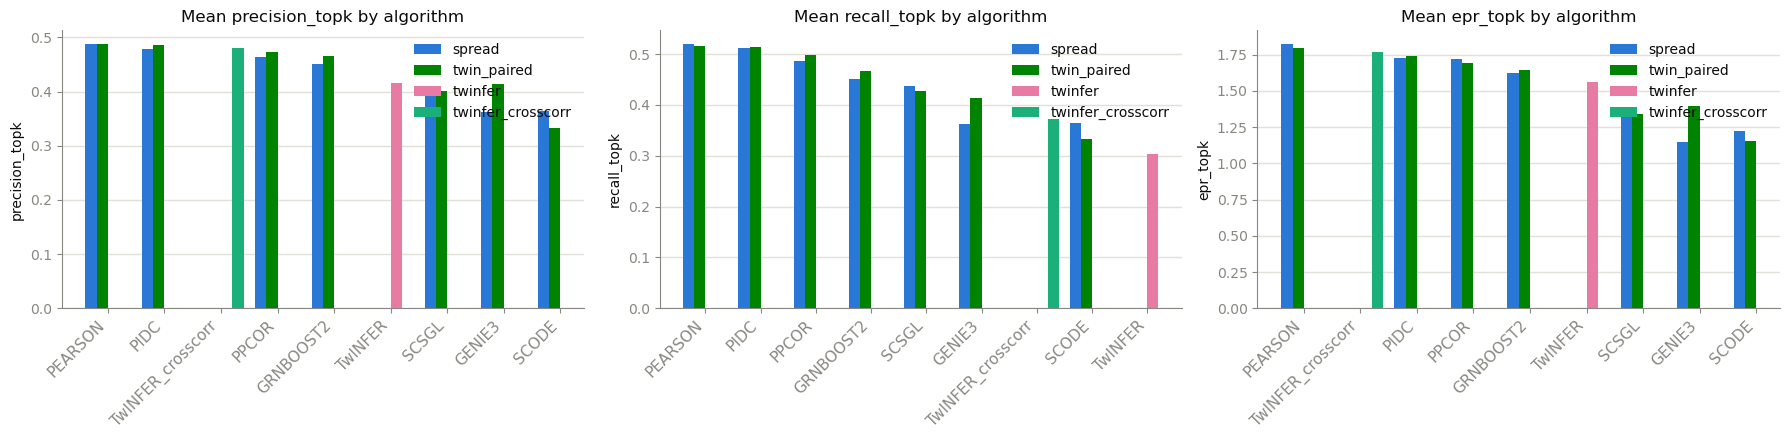

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_metric_by_algorithm("precision_topk", ax=axes[0])
plot_metric_by_algorithm("recall_topk", ax=axes[1])
plot_metric_by_algorithm("epr_topk", ax=axes[2])
fig.tight_layout()

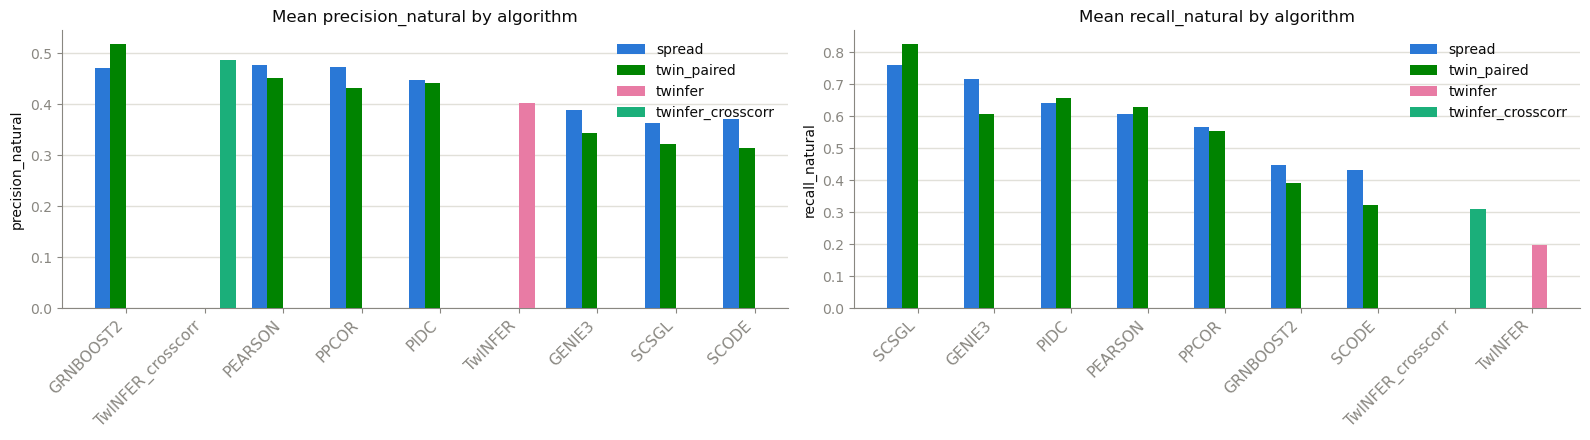

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_metric_by_algorithm("precision_natural", ax=axes[0])
plot_metric_by_algorithm("recall_natural", ax=axes[1])
fig.tight_layout()

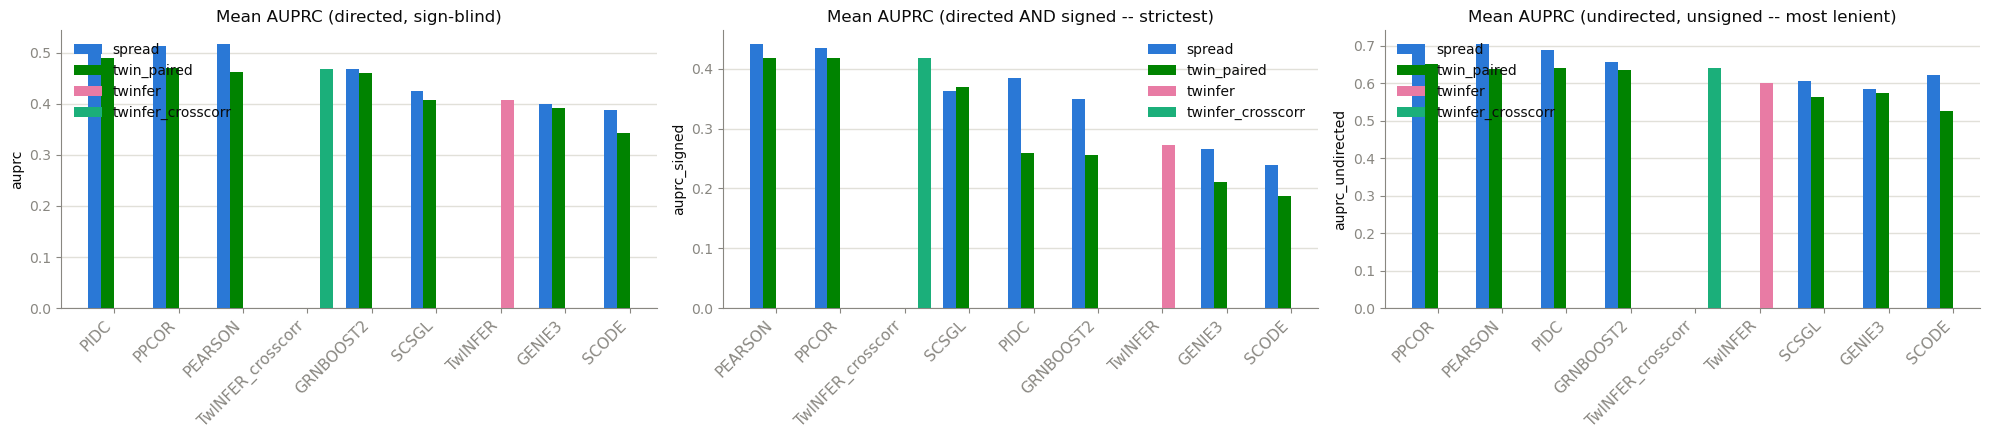

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
plot_metric_by_algorithm("auprc", ax=axes[0], title="Mean AUPRC (directed, sign-blind)")
plot_metric_by_algorithm("auprc_signed", ax=axes[1], title="Mean AUPRC (directed AND signed -- strictest)")
plot_metric_by_algorithm("auprc_undirected", ax=axes[2], title="Mean AUPRC (undirected, unsigned -- most lenient)")
fig.tight_layout()

## Distribution per individual dataset

One box (quartile spread across every algorithm x scheme x sim_rep combination evaluated on that dataset) plus jittered individual points per dataset, colored by scheme so the same categorical mapping used above still applies. This shows how much a metric varies *within* a single topology, not just its mean across topologies.

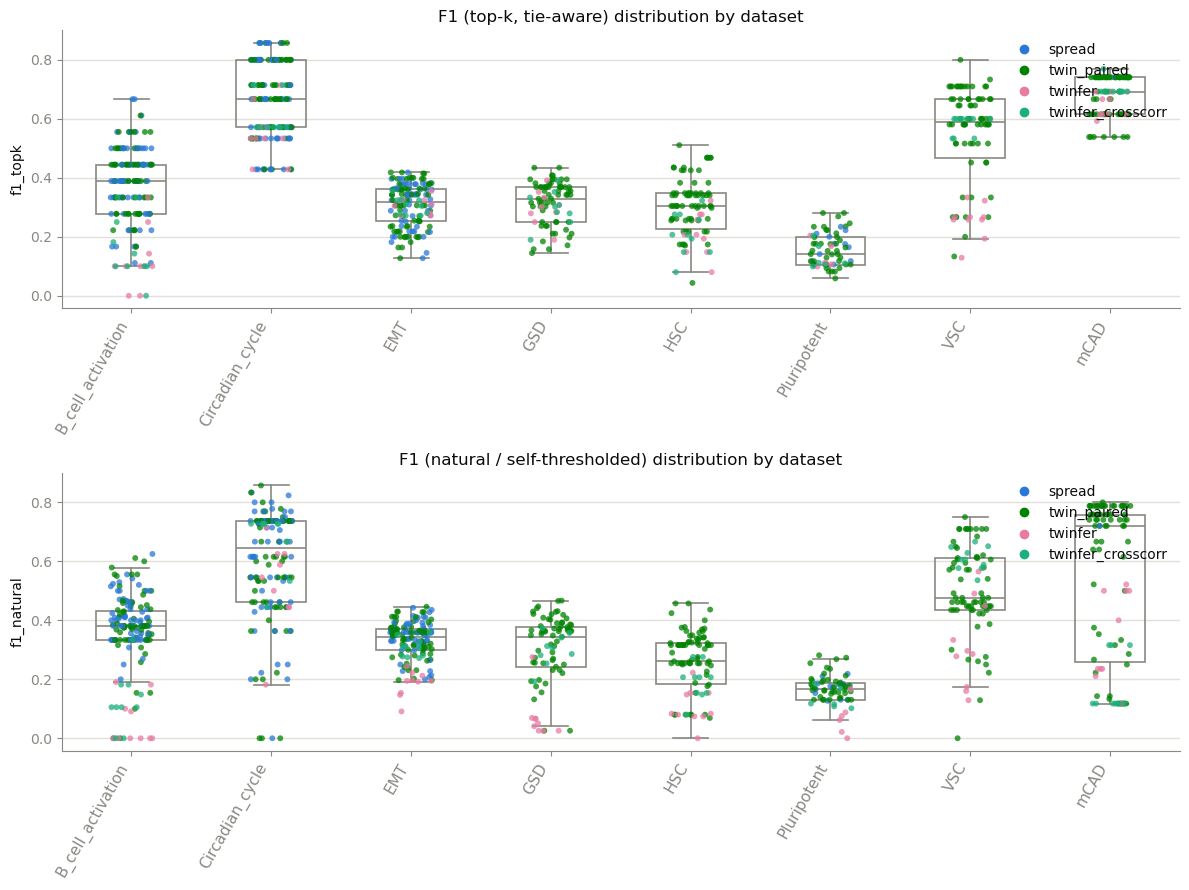

In [15]:
import numpy as np

# np.random.default_rng needs numpy>=1.17; this env pins numpy 1.15.4, so use
# the legacy RandomState API instead.
_rng = np.random.RandomState(0)


def plot_box_dot_by_dataset(metric: str, ax=None, title=None):
    dataset_ids = sorted(results["dataset_id"].unique())
    grouped = [
        results.loc[results["dataset_id"] == d, metric].dropna().values
        for d in dataset_ids
    ]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(12, 5))

    positions = range(1, len(dataset_ids) + 1)
    bp = ax.boxplot(
        grouped, positions=list(positions), widths=0.5, showfliers=False,
        patch_artist=True,
    )
    for box in bp["boxes"]:
        box.set(facecolor="none", edgecolor=INK_MUTED, linewidth=1.2, zorder=2)
    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set(color=INK_MUTED, linewidth=1.2)

    # Jittered dots on top, colored by scheme (same mapping as the bar charts above)
    for pos, dataset_id in zip(positions, dataset_ids):
        subset = results[results["dataset_id"] == dataset_id].dropna(subset=[metric])
        jitter = _rng.uniform(-0.15, 0.15, size=len(subset))
        colors = subset["scheme"].map(SCHEME_COLORS).fillna(INK_MUTED)
        ax.scatter(
            pos + jitter, subset[metric],
            color=colors, s=18, alpha=0.75, zorder=3, linewidths=0,
        )

    ax.set_xticks(list(positions))
    ax.set_xticklabels(dataset_ids, rotation=60, ha="right", color=INK_PRIMARY, fontsize=11)
    ax.set_ylabel(metric, color=INK_PRIMARY)
    ax.set_title(title or f"{metric} distribution by dataset", color=INK_PRIMARY)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED)

    # Legend for scheme colors (dots aren't from ax.bar/scatter-with-label, so build handles manually)
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=s)
        for s, c in SCHEME_COLORS.items()
        if s in results["scheme"].unique()
    ]
    legend = ax.legend(handles=handles, frameon=False, loc="upper right")
    for text in legend.get_texts():
        text.set_color(INK_PRIMARY)

    if own_ax:
        fig.tight_layout()
        return fig


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("f1_topk", ax=axes[0], title="F1 (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("f1_natural", ax=axes[1], title="F1 (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

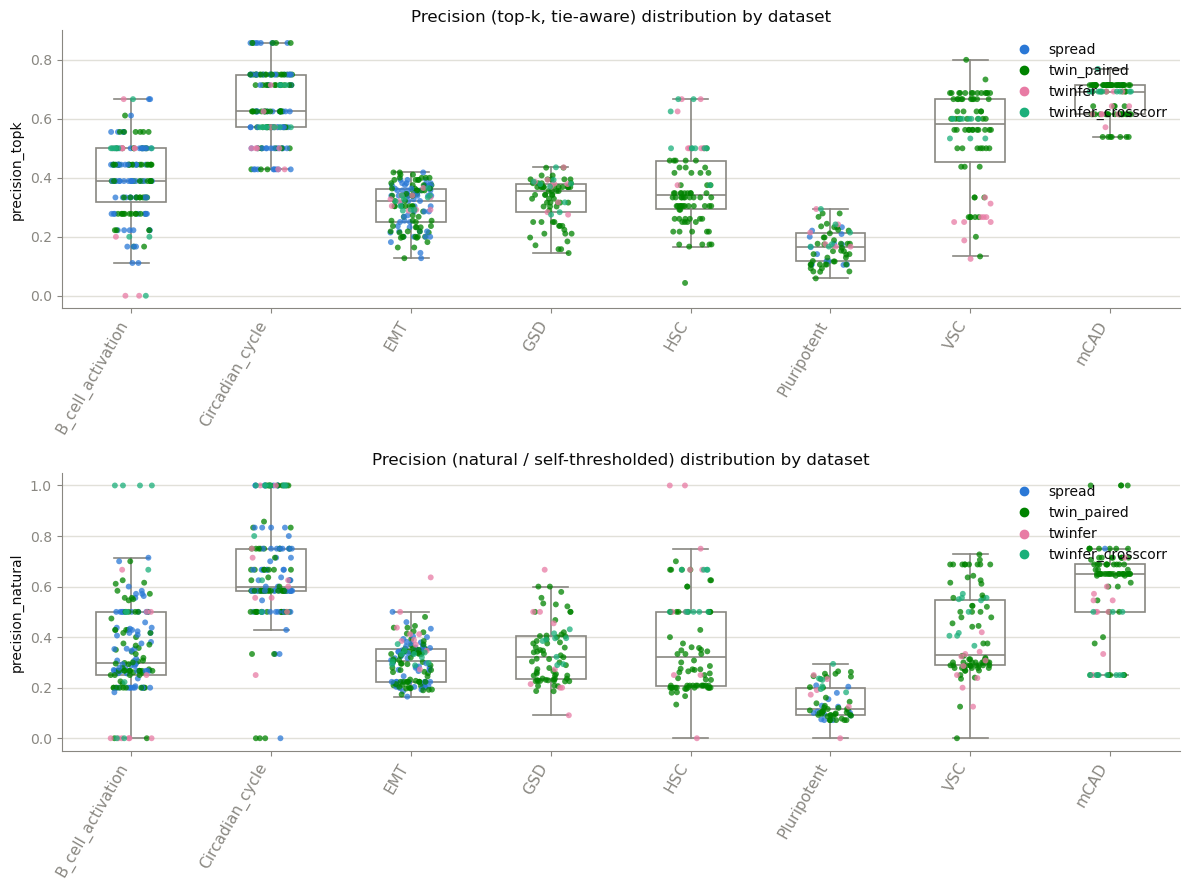

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("precision_topk", ax=axes[0], title="Precision (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("precision_natural", ax=axes[1], title="Precision (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

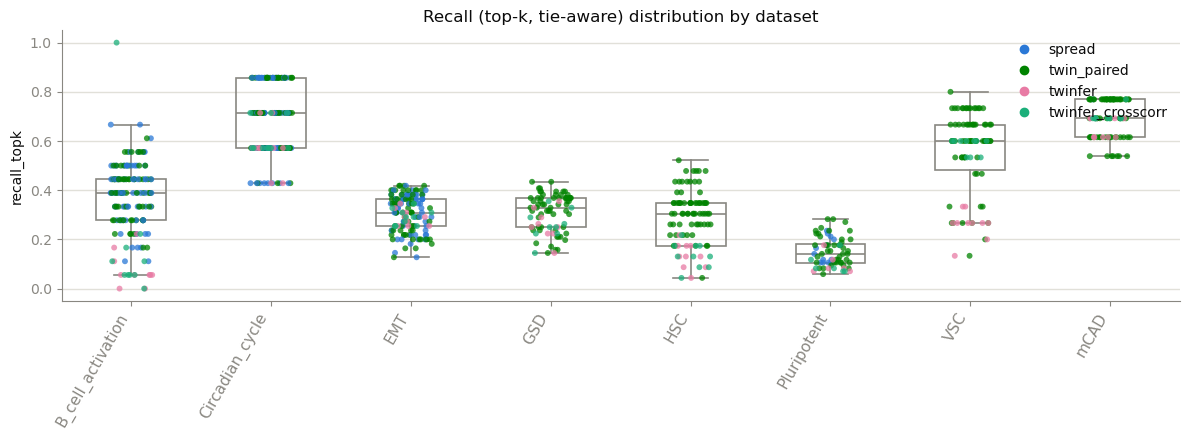

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4.5))
plot_box_dot_by_dataset("recall_topk", ax=axes, title="Recall (top-k, tie-aware) distribution by dataset")
# plot_box_dot_by_dataset("recall_natural", ax=axes[1], title="Recall (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

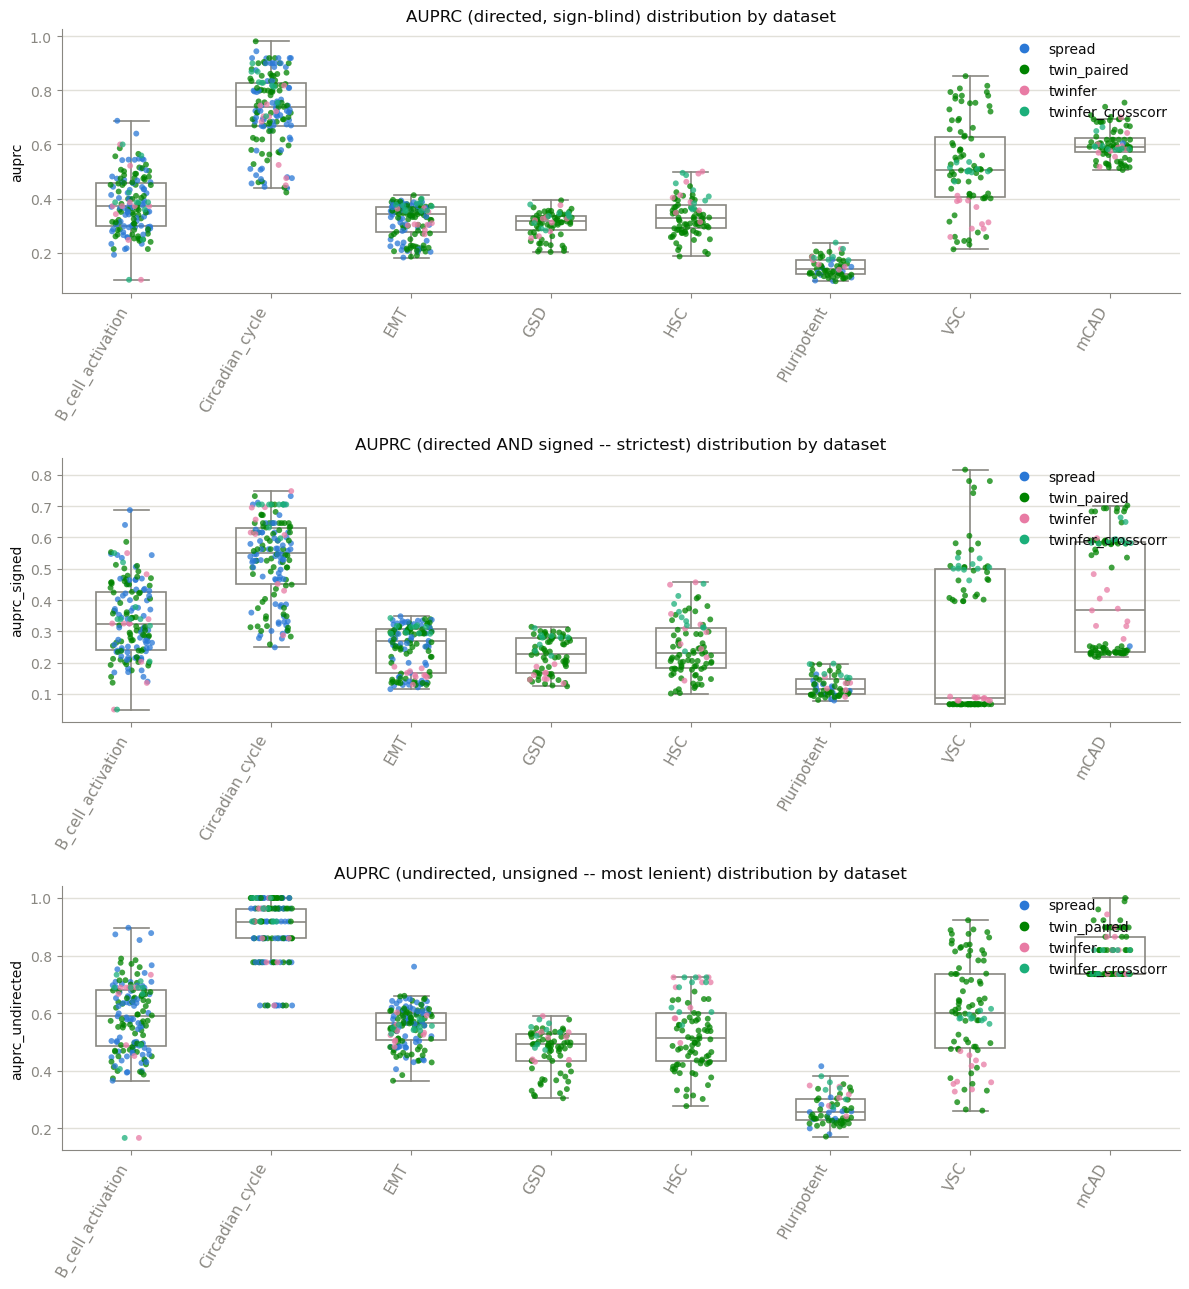

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
plot_box_dot_by_dataset("auprc", ax=axes[0], title="AUPRC (directed, sign-blind) distribution by dataset")
plot_box_dot_by_dataset("auprc_signed", ax=axes[1], title="AUPRC (directed AND signed -- strictest) distribution by dataset")
plot_box_dot_by_dataset("auprc_undirected", ax=axes[2], title="AUPRC (undirected, unsigned -- most lenient) distribution by dataset")
fig.tight_layout()

## Heatmap: every method, identified

The box/dot plots above show the spread across algorithms per dataset, but don't identify *which* dot belongs to *which* algorithm. This heatmap makes algorithm identity an explicit axis: rows = algorithm, columns = dataset (averaged across sim_reps), color = metric value, for a single sampling scheme at a time -- set `HEATMAP_SCHEME` below to `"spread"` or `"twin_paired"` to choose which (TwINFER is folded in either way, since it isn't run through a sampling scheme). Color here does a *magnitude* job, not an identity job, so it uses a single-hue-family sequential ramp (`flare`, light -> dark) rather than the categorical palette used elsewhere in this notebook -- linear scaling from true zero, no gamma stretch. Cell values are annotated directly since exact numbers matter for this kind of comparison. Two extra columns are appended on the right of every heatmap: **Average** (mean of that row's metric across all shown datasets -- the same quantity rows are already sorted by) and **Rank** (that average's rank among the shown algorithms, 1 = best). The Rank column has no color fill since rank position, not magnitude, is what it encodes.

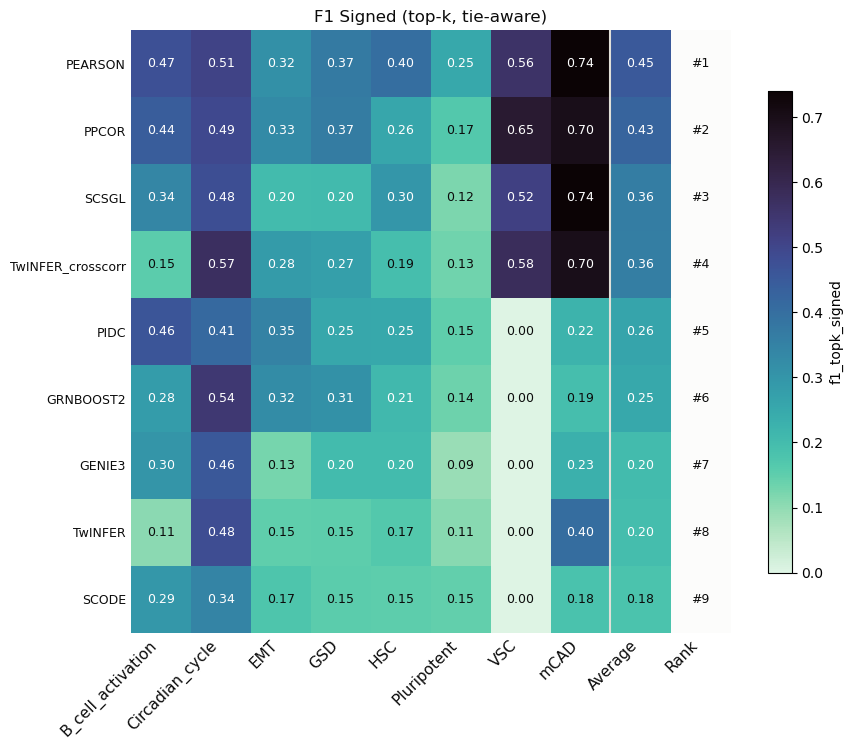

In [19]:
import seaborn as sns  # registers the "flare" colormap with matplotlib
from matplotlib.colors import Normalize

# Single-hue-family sequential colormap for magnitude encoding
HEATMAP_CMAP = sns.color_palette("mako_r", as_cmap=True)

# Neutral background for the Rank column, which is deliberately unfilled --
# rank position isn't a magnitude, so it shouldn't be pulled from the same
# color scale as the metric cells. Matches the light chart surface used
# elsewhere in this notebook's palette.
HEATMAP_SURFACE = "#fcfcfb"

# Change to "spread" or "twin_paired" -- controls which sampling scheme's
# heatmap gets rendered by every plot_heatmap_by_algorithm_dataset(...) call
# below.
HEATMAP_SCHEME = "twin_paired"

# Every dataset_id is "grn_n6_e{edges}_pos{pos}_{variant}_rep{rep}" -- n is
# fixed at 6 across the whole sweep, so it's dropped from the display label;
# pos is only informative for the sign_ratio variant (it's constant at 100
# for density/center), so it's only shown there.
DATASET_LABEL_RE = re.compile(
    r"^grn_n\d+_e(?P<e>\d+)(?:_pos(?P<pos>\d+))?_(?P<variant>density|sign_ratio|center)_rep(?P<rep>\d+)$"
)


def prettify_dataset_id(dataset_id: str) -> str:
    m = DATASET_LABEL_RE.match(dataset_id)
    if not m:
        return dataset_id
    pos_label = f"pos{m['pos']} " if m["variant"] == "sign_ratio" else ""
    return f"E{m['e']} {pos_label}{m['variant'].replace('_', ' ')} \u00b7 r{m['rep']}"


def _label_color_for(val: float, norm, cmap) -> str:
    # Pick white vs. ink by the actual rendered cell color's luminance rather
    # than assuming which end of the ramp is dark -- keeps this correct
    # regardless of which colormap HEATMAP_CMAP is set to.
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else INK_PRIMARY


def plot_heatmap_by_algorithm_dataset(metric: str, scheme: str = None, ax=None, title=None, norm=None, exclude_datasets=None):
    # TwINFER isn't run through either sampling scheme (it's its own method
    # operating on the raw twin-simulation data directly), so its row is the
    # same regardless of scheme -- fold it in for direct row-by-row
    # comparison against the BEELINE algorithms instead of segregating it.
    scheme = scheme or HEATMAP_SCHEME
    subset = results[(results["scheme"] == scheme) | (results["algorithm"].str.startswith("TwINFER"))]
    if exclude_datasets:
        subset = subset[~subset["dataset_id"].isin(exclude_datasets)]
    pivot = subset.groupby(["algorithm", "dataset_id"])[metric].mean().unstack("dataset_id")

    # Average across datasets and each row's rank by that average (1 = best)
    # -- computed before sorting so the rank doesn't just restate row order.
    row_avg = pivot.mean(axis=1)
    row_rank = row_avg.rank(ascending=False, method="min").astype(int)
    pivot = pivot.loc[row_avg.sort_values(ascending=False).index]
    row_avg = row_avg.loc[pivot.index]
    row_rank = row_rank.loc[pivot.index]

    n_dataset_cols = pivot.shape[1]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(0.6 * (n_dataset_cols + 2) + 3, 0.4 * len(pivot.index) + 4))

    # Anchored at true zero (norm.vmin == 0), plain linear scaling to vmax --
    # no gamma stretch, so cell color is directly proportional to the metric.
    # vmax is taken from the dataset cells only; Average can't exceed that.
    if norm is None:
        vmax = float(pivot.values[~pd.isna(pivot.values)].max())
        norm = Normalize(vmin=0.0, vmax=vmax)

    # Append Average (colored, same scale as the metric) and Rank (left as
    # NaN so it renders as a flat, unfilled column -- rank position isn't a
    # magnitude and shouldn't be pulled from the metric's color scale).
    grid = np.hstack([
        pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(pivot), 1), np.nan),
    ])

    display_cmap = HEATMAP_CMAP.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)

    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_dataset_cols + 1):  # dataset columns + Average
            val = grid[i, j]
            if pd.isna(val):
                continue
            label_color = _label_color_for(val, norm, HEATMAP_CMAP)
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=label_color)
        # Rank column: plain text on the unfilled background, no magnitude coloring.
        ax.text(n_dataset_cols + 1, i, f"#{row_rank.iloc[i]}", ha="center", va="center",
                 fontsize=9, color=INK_PRIMARY)

    # Separator between the per-dataset cells and the Average/Rank summary columns.
    ax.axvline(n_dataset_cols - 0.5, color=GRIDLINE, linewidth=1.5)

    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels(
        [prettify_dataset_id(c) for c in pivot.columns] + ["Average", "Rank"],
        rotation=45, ha="right", color=INK_PRIMARY, fontsize=11,
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=INK_PRIMARY, fontsize=9)
    ax.set_title(title or f"{metric} -- {scheme}", color=INK_PRIMARY)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    if own_ax:
        fig.colorbar(im, ax=ax, shrink=0.8, label=metric)
        fig.tight_layout()
        return fig
    return im


plot_heatmap_by_algorithm_dataset("f1_topk_signed", title=f"F1 Signed (top-k, tie-aware)");

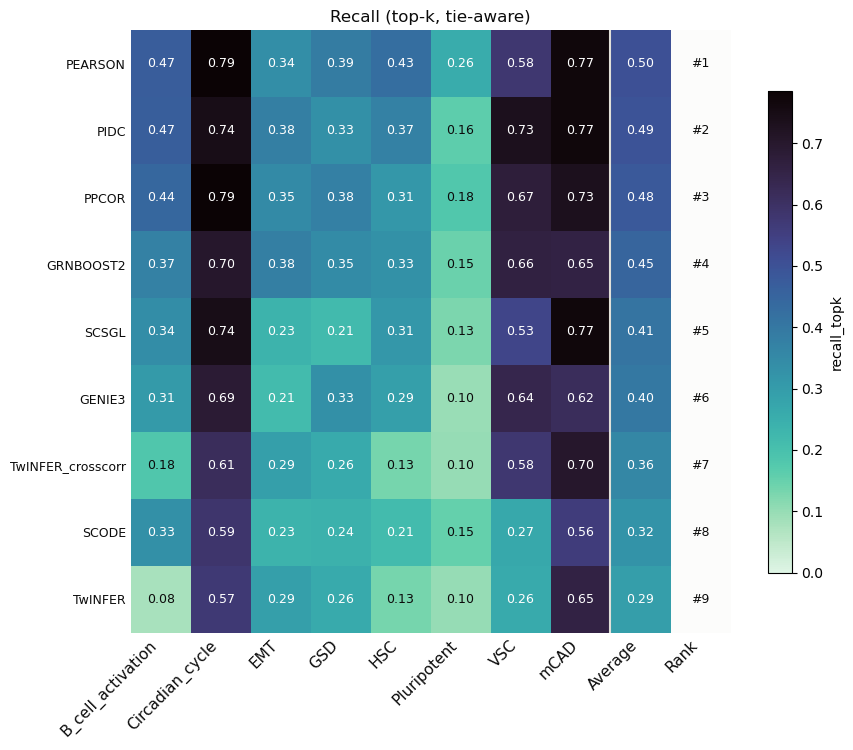

In [20]:
plot_heatmap_by_algorithm_dataset("recall_topk", title=f"Recall (top-k, tie-aware)");

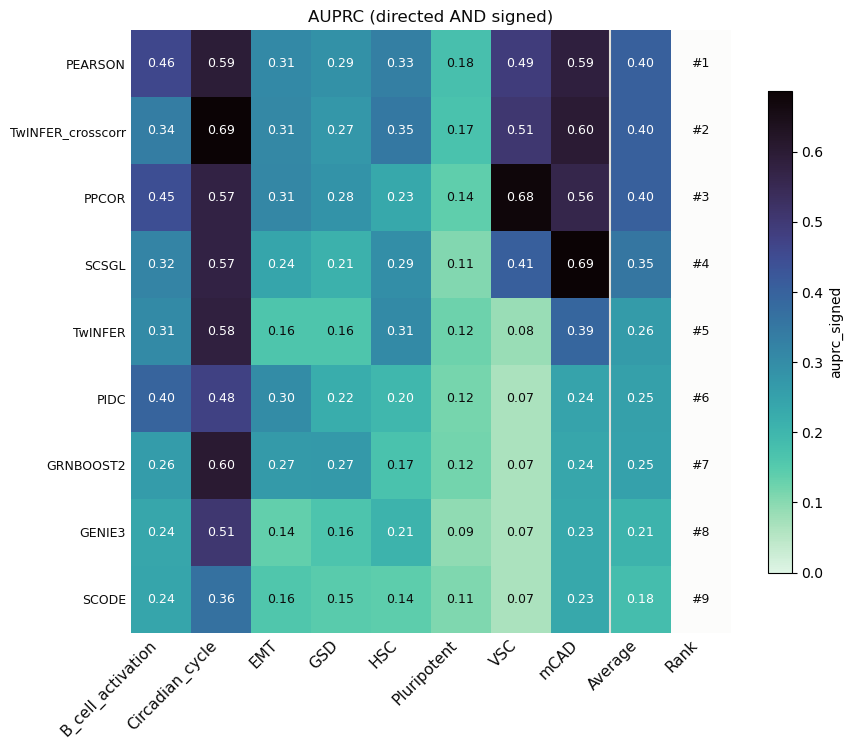

In [21]:
plot_heatmap_by_algorithm_dataset("auprc_signed", title=f"AUPRC (directed AND signed)");

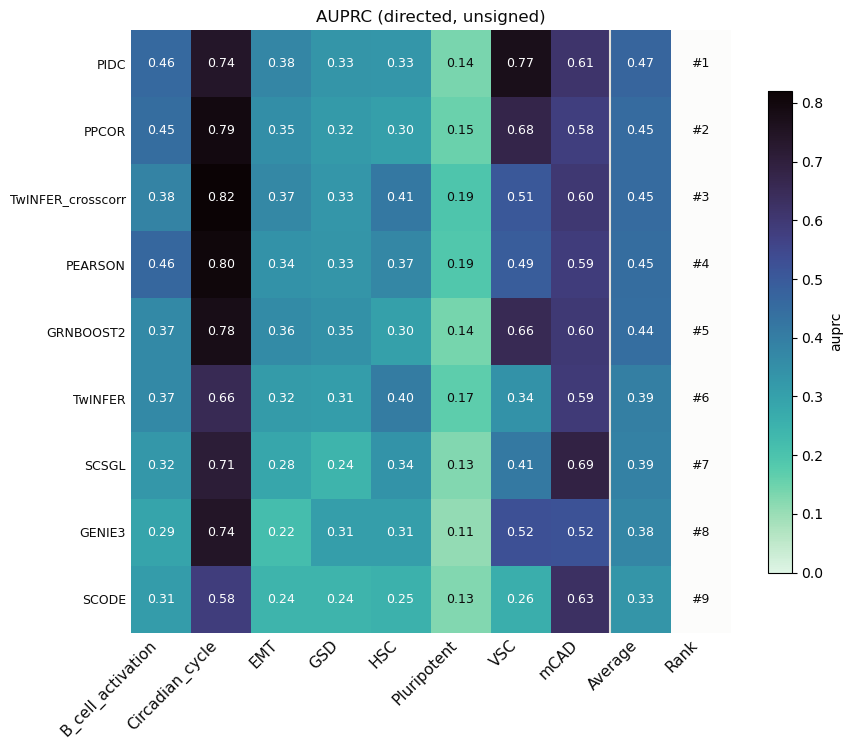

In [22]:
plot_heatmap_by_algorithm_dataset("auprc", title=f"AUPRC (directed, unsigned)");

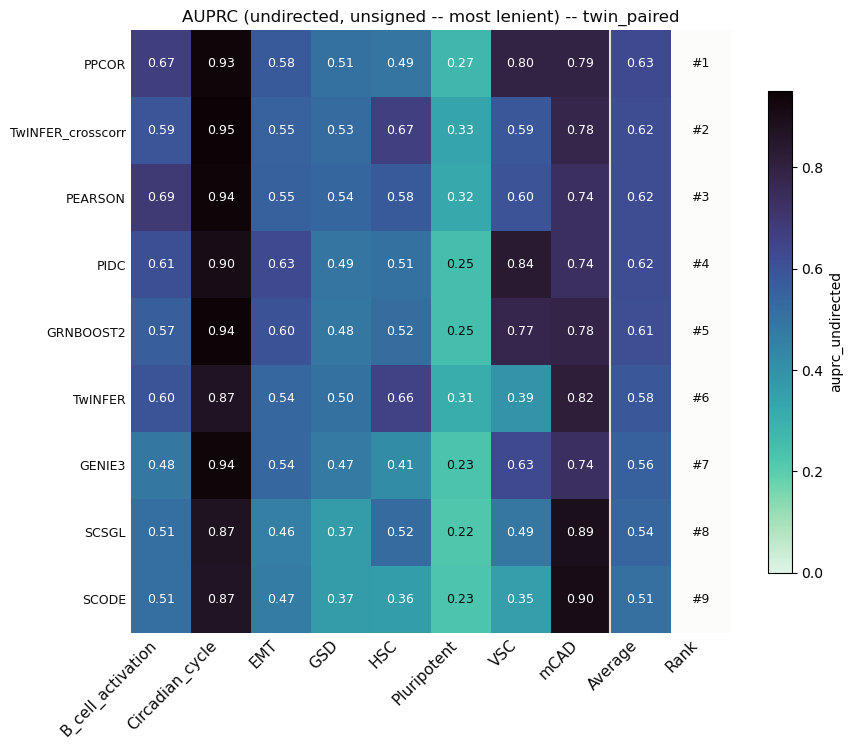

In [23]:
plot_heatmap_by_algorithm_dataset("auprc_undirected", title=f"AUPRC (undirected, unsigned -- most lenient) -- {HEATMAP_SCHEME}");

## F1 and AUPRC, every method including both TwINFER rankings

All 9 methods side by side -- the 7 BEELINE algorithms, `TwINFER` (ranked by TwinScore), and
`TwINFER_crosscorr` (ranked by raw cross-correlation magnitude, `direction.unfiltered_matrix`) --
so the two TwINFER rankings can be compared directly against each other and against BEELINE, not
just against each other. One fixed algorithm order (by mean `f1_topk`, descending) across every
panel. Top row: unsigned directed (the default variant); bottom row: signed directed, since that
is where the two TwINFER rankings diverge most (see the TwinScore-vs-cross-correlation sign
discussion above).


In [ ]:
f1_auprc_order = results.groupby("algorithm")["f1_topk"].mean().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_metric_by_algorithm("f1_topk", ax=axes[0, 0], title="F1 (top-k, tie-aware) -- unsigned directed", order=f1_auprc_order)
plot_metric_by_algorithm("auprc", ax=axes[0, 1], title="AUPRC -- unsigned directed", order=f1_auprc_order)
plot_metric_by_algorithm("f1_topk_signed", ax=axes[1, 0], title="F1 (top-k, tie-aware) -- signed directed", order=f1_auprc_order)
plot_metric_by_algorithm("auprc_signed", ax=axes[1, 1], title="AUPRC -- signed directed", order=f1_auprc_order)
fig.suptitle(
    f"F1 and AUPRC across all {results['dataset_id'].nunique()} real networks -- "
    f"both TwINFER rankings vs. every BEELINE method",
    color=INK_PRIMARY, fontsize=14, y=1.01,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "real_networks_f1_auprc_both_twinfer.png", dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved to {OUT_DIR / 'real_networks_f1_auprc_both_twinfer.png'}")

## Final summary: every method x every metric family x every strictness variant, all 8 real networks

3x3 grid in the style used elsewhere in this project's benchmarks -- rows = metric family (AUPRC, F1 top-k,
F1 threshold/natural), columns = strictness variant (signed directed, unsigned directed, unsigned undirected).
Each panel is `plot_heatmap_by_algorithm_dataset` unchanged (algorithm rows sorted by descending average,
dataset columns, Average + Rank summary columns, TwINFER folded in regardless of `HEATMAP_SCHEME`) -- only the
layout changes, sharing one 0-1 color scale and one colorbar across all nine panels so magnitude is directly
comparable panel to panel.


Saved to /gpfs/projects/b1255/hzhang/TwINFER_KA/analysis_data/paper_analysis/real_networks/real_networks_full_metric_grid.png


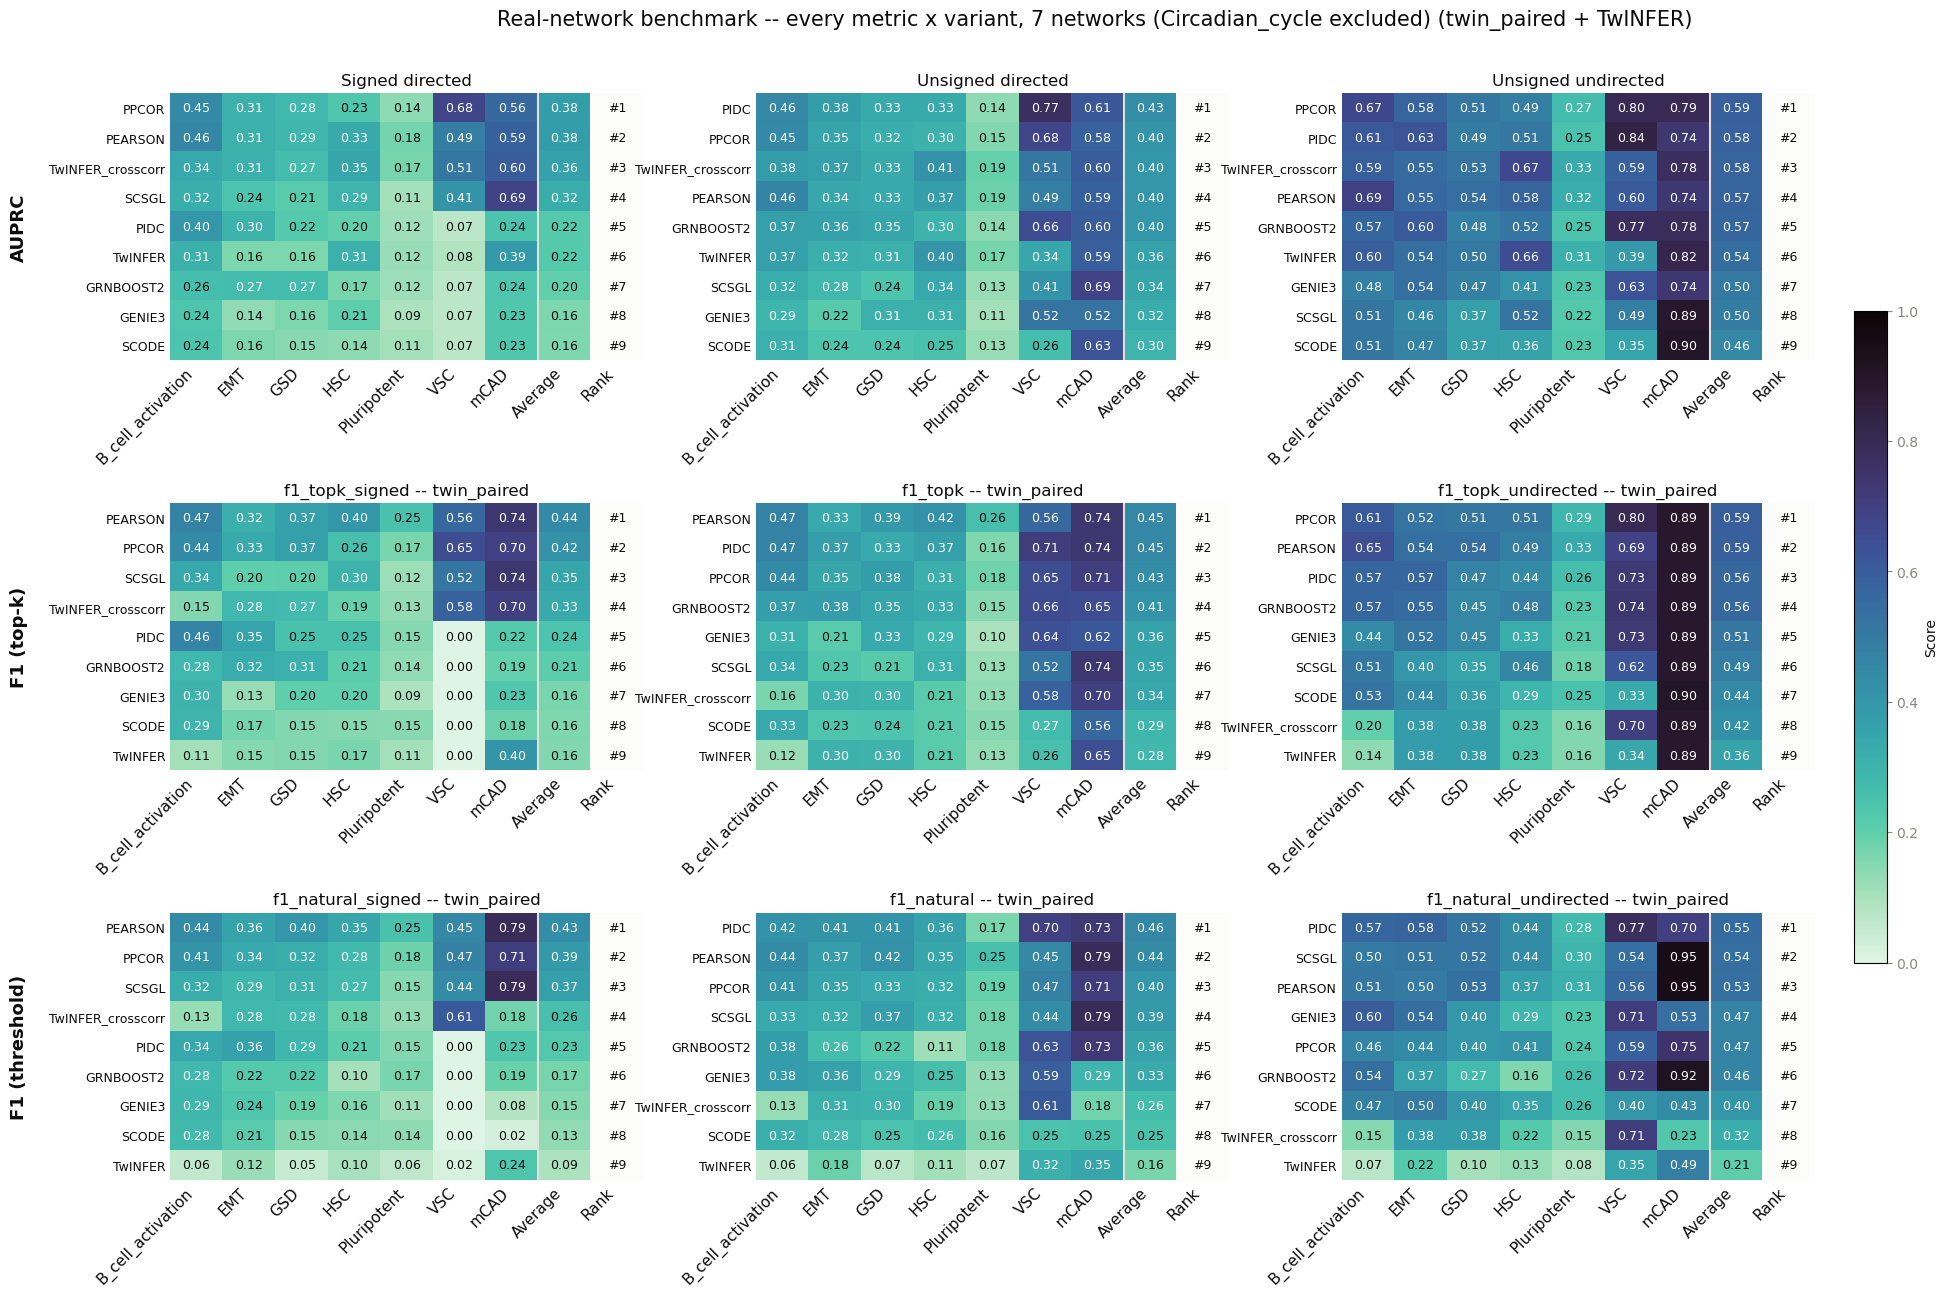

In [24]:
METRIC_GRID = [
    ("AUPRC", ["auprc_signed", "auprc", "auprc_undirected"]),
    ("F1 (top-k)", ["f1_topk_signed", "f1_topk", "f1_topk_undirected"]),
    ("F1 (threshold)", ["f1_natural_signed", "f1_natural", "f1_natural_undirected"]),
]
VARIANT_TITLES = ["Signed directed", "Unsigned directed", "Unsigned undirected"]

n_dataset_cols = results["dataset_id"].nunique() - 1  # Circadian_cycle excluded from this grid
fig, axes = plt.subplots(
    3, 3,
    figsize=(3.1 * (n_dataset_cols + 2) * 0.62 + 6, 3.6 * 3 + 2),
)

shared_norm = Normalize(vmin=0.0, vmax=1.0)
im = None
for row, (family_label, metrics) in enumerate(METRIC_GRID):
    for col, metric in enumerate(metrics):
        ax = axes[row, col]
        title = VARIANT_TITLES[col] if row == 0 else None
        im = plot_heatmap_by_algorithm_dataset(metric, ax=ax, title=title, norm=shared_norm, exclude_datasets=["Circadian_cycle"])
    axes[row, 0].annotate(
        family_label, xy=(-0.32, 0.5), xycoords="axes fraction",
        rotation=90, va="center", ha="center", fontsize=13, fontweight="bold", color=INK_PRIMARY,
    )

fig.suptitle(
    f"Real-network benchmark -- every metric x variant, {n_dataset_cols} networks (Circadian_cycle excluded) "
    f"({HEATMAP_SCHEME} + TwINFER)",
    color=INK_PRIMARY, fontsize=15, y=1.01,
)
fig.tight_layout(rect=[0.02, 0, 0.96, 1])
cbar = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02, label="Score")
cbar.ax.yaxis.label.set_color(INK_PRIMARY)
cbar.ax.tick_params(colors=INK_MUTED)

fig.savefig(OUT_DIR / "real_networks_full_metric_grid.png", dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved to {OUT_DIR / 'real_networks_full_metric_grid.png'}")

## Notes

- **EPR** (Early Precision Ratio) is `precision_topk / random_baseline_precision` -- values above 1 mean better than random chance for that dataset's edge density; included since it's directly comparable to BEELINE's own published numbers.
- Compare `n_selected_natural` to `n_true_edges` per algorithm in the summary table above: if they're close, `f1_topk` and `f1_natural` should roughly agree; a big gap between the two F1 columns for a given algorithm is the signal that it's the "outputs its own fixed network" type, and `f1_natural` is the fairer number to cite for it. TwINFER's natural numbers here are close to meaningless in isolation for the reason noted in the title cell (its `ranked_edge_list` is essentially always nonzero) -- treat `f1_topk` as the more informative TwINFER number unless `final_directed_edges` gets wired in as its natural cutoff instead.
- Algorithms with `should_run: [False]` in the BEELINE config simply won't have `rankedEdges.csv` files and are silently absent from these tables rather than erroring -- check the BEELINE run config for this sweep if an expected algorithm x dataset combination is missing.
- If `BLRunner.py`'s per-runner error handling caused some (dataset, run, algorithm) combination to fail outright, it also won't appear here -- cross-check against the "N of M run(s) failed" summary `BLRunner.py` prints at the end of a benchmark pass.
- **`_signed` and `_undirected` columns**: three strictness levels are computed side by side for every algorithm -- the original columns (directed, sign-blind), `_signed` (directed AND signed -- any mismatch is incorrect, the strictest), and `_undirected` (existence only, ignoring both direction and sign -- the most lenient). Expect `precision_undirected >= precision >= precision_signed` for a given algorithm/threshold, since each step only relaxes what counts as a match. Unlike `network_sweep_final`, TwINFER's numbers here (including all three `auprc*` columns) come from the exact same generic scoring functions as the BEELINE algorithms, not a separately precomputed CSV -- see the title cell for how.